# Conexão e Acesso aos Dados do Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Após montar o Google Drive, seus datasets estarão acessíveis. A pasta do seu projeto é `/content/drive/MyDrive/TDE 01 - IA/`. Definiremos aqui o caminho para o arquivo `train_transaction.csv` para uso consistente em todo o notebook.

In [2]:
import os

drive_folder_path = '/content/drive/MyDrive/TDE 01 - IA/'

print(f"Conteúdo da pasta '{drive_folder_path}':")
try:
    for file_name in os.listdir(drive_folder_path):
        print(file_name)
except FileNotFoundError:
    print(f"Erro: A pasta '{drive_folder_path}' não foi encontrada.")
except Exception as e:
    print(f"Ocorreu um erro ao listar o conteúdo da pasta: {e}")

Conteúdo da pasta '/content/drive/MyDrive/TDE 01 - IA/':
test_identity.csv
sample_submission.csv
test_transaction.csv
train_identity.csv
train_transaction.csv


In [3]:
import pandas as pd

# Carrega o dataset de transações de treino
transaction_df = pd.read_csv('/content/drive/MyDrive/TDE 01 - IA/train_transaction.csv')

print('Dataset de transações de treino carregado com sucesso! Primeiras 5 linhas:')
display(transaction_df.head())
print('\nInformações básicas do dataset de transações de treino:')
transaction_df.info()

Dataset de transações de treino carregado com sucesso! Primeiras 5 linhas:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Informações básicas do dataset de transações de treino:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [4]:
# Carrega o dataset de identidade de treino
identity_df = pd.read_csv('/content/drive/MyDrive/TDE 01 - IA/train_identity.csv')

print('\nDataset de identidade de treino carregado com sucesso! Primeiras 5 linhas:')
display(identity_df.head())
print('\nInformações básicas do dataset de identidade de treino:')
identity_df.info()


Dataset de identidade de treino carregado com sucesso! Primeiras 5 linhas:


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS



Informações básicas do dataset de identidade de treino:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          12

### Combinando os Datasets de Transação e Identidade

Para ter uma visão completa das transações e das informações de identidade associadas, vamos agora combinar os dois dataframes (`transaction_df` e `identity_df`). A coluna `TransactionID` será usada como chave para a mesclagem.

In [5]:
# Combinando os dataframes
df_train = pd.merge(transaction_df, identity_df, on='TransactionID', how='left')

print('\nDatasets combinados com sucesso! Primeiras 5 linhas do dataframe final:')
display(df_train.head())
print('\nInformações básicas do dataframe combinado:')
df_train.info()

print(f'Shape do dataframe combinado: {df_train.shape}')


Datasets combinados com sucesso! Primeiras 5 linhas do dataframe final:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M



Informações básicas do dataframe combinado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB
Shape do dataframe combinado: (590540, 434)


Para ler o conteúdo de um arquivo PDF em Python, podemos usar a biblioteca `PyMuPDF` (também conhecida como `fitz`). Primeiro, precisamos instalá-la.

In [6]:
pip install PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 25.4 MB/s eta 0:00:00


Agora, vamos extrair o texto do PDF fornecido e exibi-lo para que possamos analisar os requisitos do projeto.

# TDE 01 - Análise Exploratória de Dados: Detecção de Fraudes em Compras

## Descrição
A detecção de fraudes em cartões de crédito é fundamental para proteger tanto os consumidores quanto as instituições financeiras contra atividades ilícitas. O uso de técnicas de aprendizado de máquina tem papel central nesse processo, ao possibilitar a identificação de padrões complexos e anomalias em dados de transações. Por meio da análise automatizada de grandes volumes de informações em tempo real, algoritmos são capazes de detectar comportamentos suspeitos com rapidez e precisão. Essa capacidade é essencial para a mitigação de riscos e a prevenção de perdas financeiras. Ao adotar métodos avançados de aprendizado de máquina, as empresas podem fortalecer suas estratégias de segurança e garantir transações mais seguras para seus clientes.

O conjunto de dados utilizado neste projeto é composto por 100 mil registros reais de transações online, fornecidos pela empresa Vesta. Cada transação é representada por um conjunto de atributos que incluem tanto informações sobre a própria compra, como o valor e o tempo da transação, quanto dados sobre a conexão de rede utilizada, como endereço IP e tipo de dispositivo.

## Objetivo Principal
Este projeto envolve um problema de classificação binária, cujo objetivo é indicar se a transação é fraudulenta. As métricas empregadas na comparação entre as soluções candidatas neste projeto são a Acurácia Balanceada e a Área sob a Curva ROC.

## Técnicas Envolvidas
*   Processamento de Dados Tabulares.
*   Balanceamento de Dados.
*   Tratamento de Dados Faltantes.
*   Classificação Binária.

## Desafios:
*   Explorar técnicas de processamento de dados tabulares.
*   Lidar com desbalanceamento de dados.
*   Realizar o tratamento de dados faltantes.
*   Classificar corretamente transações fraudulentas.

## 2. Conhecimento Inicial dos Dados

Nesta seção, será realizada uma investigação preliminar do conjunto de dados para compreender sua estrutura, os tipos de variáveis e algumas de suas características estatísticas.

### 2.1 Carregamento dos dados

Inicialmente, será realizada a leitura do conjunto de dados de treinamento (`train_transaction.csv`), que contém informações sobre as transações e a variável `isFraud`, utilizada para identificar se uma transação é fraudulenta ou não.


In [7]:
# Esta célula carregava o DataFrame 'df' completo, mas o restante da análise utiliza o 'transaction_df' com um subconjunto de colunas.
# O carregamento principal do 'transaction_df' é feito na célula 758c0b19.
# Para evitar redundância e confusão, esta célula foi comentada/limpa.

### 2.2 Dimensões do conjunto de dados

Para compreender o tamanho da base utilizada, serão verificadas a quantidade de linhas e colunas presentes no conjunto de dados.


In [8]:
linhas, colunas = transaction_df.shape

print(f"Quantidade de linhas: {linhas}")
print(f"Quantidade de colunas: {colunas}")

Quantidade de linhas: 590540
Quantidade de colunas: 394


### 2.3 Tipos e classificação das variáveis

A seguir, serão analisados os tipos de dados presentes no conjunto de dados, permitindo identificar quais variáveis são numéricas e quais são categóricas.

In [9]:
# Informações sobre as variáveis
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [10]:
# Variáveis numéricas
variaveis_numericas = transaction_df.select_dtypes(include="number").columns

print("Quantidade de variáveis numéricas:", len(variaveis_numericas))

# Variáveis categóricas
variaveis_categoricas = transaction_df.select_dtypes(include=["object", "category"]).columns

print("Quantidade de variáveis categóricas:", len(variaveis_categoricas))

Quantidade de variáveis numéricas: 380
Quantidade de variáveis categóricas: 14


Para facilitar a compreensão inicial dos dados, foram selecionadas algumas das principais variáveis presentes no conjunto de dados. Essas variáveis estão relacionadas à identificação da transação, à ocorrência de fraude, ao tempo da transação, ao valor da compra, ao produto e às informações do cartão. A tabela a seguir apresenta os tipos de dados dessas variáveis:

In [11]:
principais_variaveis = [
    "TransactionID",
    "isFraud",
    "TransactionDT",
    "TransactionAmt",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5"
]

transaction_df[principais_variaveis].dtypes.to_frame("Tipo")

,Tipo
TransactionID,int64
isFraud,int64
TransactionDT,int64
TransactionAmt,float64
ProductCD,object
card1,int64
card2,float64
card3,float64
card4,object
card5,float64


### 2.4 Identificação de variáveis temporais

Entre as variáveis disponíveis, `TransactionDT` representa uma informação temporal relacionada ao momento em que a transação ocorreu. Essa variável utiliza uma medida de tempo relativa, sendo importante para analisar a distribuição das transações ao longo do período observado.


In [12]:
# Verificação da variável temporal
transaction_df["TransactionDT"].describe()

,TransactionDT
count,5.905400e+05
mean,7.372311e+06
std,4.617224e+06
min,8.640000e+04
25%,3.027058e+06
50%,7.306528e+06
75%,1.124662e+07
max,1.581113e+07


`TransactionDT` apresenta valores numéricos que representam o tempo relativo das transações. Os valores variam de aproximadamente **86 mil a 15,8 milhões**, indicando transações distribuídas ao longo de um período.


### 2.5 Estatísticas descritivas

Para obter uma visão inicial do comportamento das variáveis numéricas, serão calculadas medidas estatísticas como média, desvio padrão, valores mínimo e máximo e quartis.

In [13]:
# Estatísticas descritivas das variáveis numéricas
transaction_df.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
...,...,...,...,...,...,...,...,...
V335,82351.0,5.916455e+01,3.876295e+02,0.000,0.000,0.000,0.00,5.512500e+04
V336,82351.0,2.853090e+01,2.745769e+02,0.000,0.000,0.000,0.00,5.512500e+04
V337,82351.0,5.535242e+01,6.684868e+02,0.000,0.000,0.000,0.00,1.040600e+05
V338,82351.0,1.511605e+02,1.095034e+03,0.000,0.000,0.000,0.00,1.040600e+05


As estatísticas mostram diferentes escalas e distribuições entre as variáveis numéricas. A variável `TransactionAmt`, por exemplo, apresenta valores entre **0,25 e 31.937,39**, enquanto `isFraud` varia entre **0 e 1**, representando as duas classes de transação.


### 2.6 Distribuição inicial da variável `isFraud`

A variável `isFraud` indica se uma transação foi classificada como fraudulenta. Sua distribuição será analisada para verificar a proporção entre transações legítimas e fraudulentas e identificar um possível desbalanceamento dos dados.


In [14]:
# Quantidade de transações por classe
transaction_df["isFraud"].value_counts()

,count
isFraud,
0,569877
1,20663


In [15]:
# Percentual de cada classe
transaction_df["isFraud"].value_counts(normalize=True) * 100

,proportion
isFraud,
0,96.500999
1,3.499001


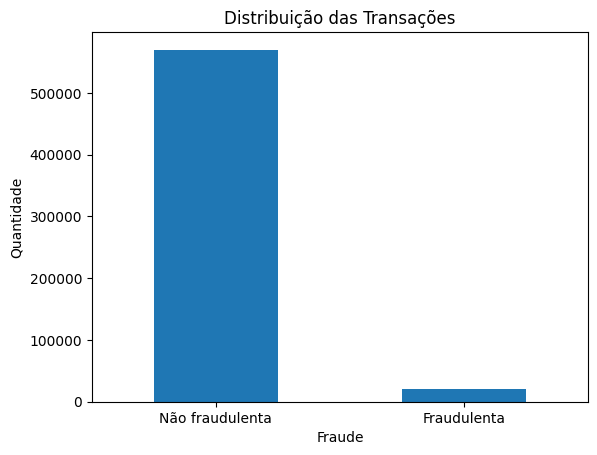

In [16]:
import matplotlib.pyplot as plt

transaction_df["isFraud"].value_counts().plot(kind="bar")

plt.title("Distribuição das Transações")
plt.xlabel("Fraude")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Não fraudulenta", "Fraudulenta"], rotation=0)
plt.show()

A análise inicial permitiu identificar a dimensão do conjunto de dados, os diferentes tipos de variáveis presentes e a existência de uma variável temporal representada por `TransactionDT`. As estatísticas descritivas também evidenciaram diferenças nas escalas e distribuições das variáveis numéricas. Além disso, a distribuição de `isFraud` revelou uma predominância de transações não fraudulentas, indicando um possível desbalanceamento entre as classes. Essas características serão consideradas nas etapas posteriores da análise exploratória.

## 3. Qualidade dos Dados

A análise inicial da qualidade dos dados foi realizada considerando 590.540 registros e 13 variáveis selecionadas do conjunto de dados de transações. O objetivo dessa etapa foi identificar valores ausentes, registros duplicados, inconsistências nos tipos de dados, valores negativos e possíveis valores discrepantes que pudessem influenciar as análises posteriores.


## 3.1 Valores ausentes

Foram identificadas **sete variáveis com valores ausentes**. As maiores proporções foram observadas nas variáveis `addr1` e `addr2`, ambas com **65.706 valores ausentes**, correspondendo a aproximadamente **11,13%** dos registros. Também foram identificados valores ausentes em `card2` (1,51%), `card5` (0,72%), `card4` (0,27%), `card6` (0,27%) e `card3` (0,27%).

A presença de dados ausentes não implica necessariamente que os registros sejam inválidos, especialmente considerando que algumas informações relacionadas ao cartão ou ao endereço podem não estar disponíveis em determinadas transações. Por esse motivo, os valores ausentes não serão removidos automaticamente nesta etapa. O tratamento dessas informações deverá considerar a natureza de cada variável e sua possível relevância para a identificação de transações fraudulentas.

## 3.2 Registros duplicados

A análise não identificou registros completamente duplicados no conjunto analisado. Foram encontrados **0 registros duplicados**, correspondendo a **0,00%** da base. Dessa forma, não houve necessidade de remoção de registros por duplicidade.

## 3.3 Distribuição da variável alvo

A variável `isFraud`, utilizada como variável alvo para indicar se uma transação é fraudulenta, apresentou **forte desbalanceamento entre suas classes**. Do total de registros, **569.877 (96,50%)** correspondem a transações legítimas, enquanto **20.663 (3,50%)** correspondem a transações fraudulentas.

Esse resultado evidencia uma característica importante do problema de detecção de fraudes: a classe fraudulenta representa uma parcela pequena das transações. Portanto, análises e modelos posteriores devem considerar esse desbalanceamento, pois uma classificação que favoreça excessivamente a classe majoritária pode apresentar um desempenho aparentemente bom sem identificar adequadamente as fraudes.

## 3.4 Tipos de dados

Entre as 13 variáveis analisadas, foram identificadas **10 variáveis numéricas e 3 variáveis categóricas**. As variáveis `ProductCD`, `card4` e `card6` foram classificadas como categóricas, apresentando, respectivamente, **5, 4 e 4 valores únicos**.

Também foi observado que `TransactionDT`, apesar de estar armazenada como uma variável do tipo inteiro (`int64`), representa uma informação relacionada ao tempo da transação. Essa característica deverá ser considerada nas análises posteriores, principalmente em possíveis investigações de comportamento temporal.

## 3.5 Valores negativos

Não foram encontrados valores negativos entre as variáveis numéricas analisadas. Esse resultado indica que, dentro das variáveis avaliadas, não foram identificados valores que apresentassem esse tipo de inconsistência.

## 3.6 Possíveis outliers

Para investigar possíveis valores discrepantes na variável `TransactionAmt`, foi utilizado o método do **intervalo interquartil (IQR)**. O primeiro quartil apresentou valor de **43,32** e o terceiro quartil apresentou valor de **125,00**, resultando em um IQR de **81,68**. A partir desses valores, foi estabelecido um limite superior de **247,52** para identificação de possíveis outliers.

Foram identificadas **66.482 transações** acima dos limites definidos, correspondendo a aproximadamente **11,26%** dos registros analisados. Entre essas transações consideradas possíveis outliers, **5,07% eram fraudulentas**, enquanto **94,93% eram legítimas**.

Os possíveis outliers não serão removidos automaticamente. Em um problema de detecção de fraudes, valores elevados de transação podem representar tanto comportamentos legítimos quanto situações potencialmente relacionadas à fraude. Portanto, a exclusão desses registros poderia eliminar informações relevantes para a análise. Esses valores serão mantidos inicialmente e investigados nas etapas de análise univariada e bivariada.

## 3.7 Síntese da qualidade dos dados

De maneira geral, a análise identificou uma base com **590.540 registros**, sem duplicidades, mas com presença de valores ausentes em sete variáveis e forte desbalanceamento da variável alvo. Também foram identificados possíveis outliers na variável `TransactionAmt`, que correspondem a **11,26% dos registros**.

Diante desses resultados, as principais decisões adotadas foram **manter inicialmente os registros com valores ausentes e os possíveis outliers**, evitando exclusões que poderiam causar perda de informações relevantes. O desbalanceamento da variável `isFraud` também será considerado nas análises seguintes, especialmente na interpretação das relações entre as variáveis e na avaliação de estratégias para detecção das transações fraudulentas.


In [17]:
import gc

# Limpar possíveis DataFrames grandes da memória
for variavel in ['df_train', 'transaction_df', 'identity_df']:
    if variavel in globals():
        del globals()[variavel]

gc.collect()

print("Memória limpa!")

Memória limpa!


In [18]:
import pandas as pd
import numpy as np

caminho_transaction = '/content/drive/MyDrive/TDE 01 - IA/train_transaction.csv'

colunas_necessarias = [
    'TransactionID',
    'TransactionDT',
    'TransactionAmt',
    'ProductCD',
    'card1',
    'card2',
    'card3',
    'card4',
    'card5',
    'card6',
    'addr1',
    'addr2',
    'isFraud'
]

transaction_df = pd.read_csv(
    caminho_transaction,
    usecols=colunas_necessarias
)

print("Arquivo 'train_transaction.csv' carregado com sucesso, com colunas selecionadas!")
print("Dimensões:", transaction_df.shape)

display(transaction_df.head())

Arquivo 'train_transaction.csv' carregado com sucesso, com colunas selecionadas!
Dimensões: (590540, 13)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0


In [19]:
import pandas as pd
import numpy as np

caminho_transaction = '/content/drive/MyDrive/TDE 01 - IA/train_transaction.csv'

colunas_necessarias = [
    'TransactionID',
    'TransactionDT',
    'TransactionAmt',
    'ProductCD',
    'card1',
    'card2',
    'card3',
    'card4',
    'card5',
    'card6',
    'addr1',
    'addr2',
    'isFraud'
]

transaction_df = pd.read_csv(
    caminho_transaction,
    usecols=colunas_necessarias
)

print("Arquivo carregado com sucesso!")
print("Dimensões:", transaction_df.shape)

display(transaction_df.head())

Arquivo carregado com sucesso!
Dimensões: (590540, 13)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0


In [20]:
print('=' * 60)
print('3. QUALIDADE DOS DATOS')
print('=' * 60)

3. QUALIDADE DOS DATOS


## 3.1 Valores Ausentes

In [21]:
print('=' * 60)
print('3.1 VALORES AUSENTES')
print('=' * 60)

missing_count = transaction_df.isnull().sum()
missing_percent = (missing_count / len(transaction_df)) * 100

missing_df = pd.DataFrame({
    'Valores Ausentes': missing_count,
    'Percentual (%)': missing_percent
})

missing_df = missing_df[missing_df['Valores Ausentes'] > 0]
missing_df = missing_df.sort_values(
    by='Percentual (%)',
    ascending=False
)

print(f"Colunas com valores ausentes: {len(missing_df)}")

display(missing_df)

3.1 VALORES AUSENTES
Colunas com valores ausentes: 7


,Valores Ausentes,Percentual (%)
addr2,65706,11.126427
addr1,65706,11.126427
card2,8933,1.512683
card5,4259,0.721204
card4,1577,0.267044
card6,1571,0.266028
card3,1565,0.265012


## 3.2 Registros duplicados

In [22]:
# Contagem de registros duplicados
duplicated_rows = transaction_df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicated_rows}")
print(f"Percentual de registros duplicados: {(duplicated_rows / len(transaction_df)) * 100:.2f}%")

if duplicated_rows == 0:
    print("Nenhum registro completamente duplicado foi encontrado.")
else:
    print("Registros duplicados encontrados e não removidos nesta etapa.")

Quantidade de registros duplicados: 0
Percentual de registros duplicados: 0.00%
Nenhum registro completamente duplicado foi encontrado.


## 3.3 Tipos de dados (Confirmação da seção 2.3)

In [23]:
# Confirmando a quantidade de variáveis numéricas e categóricas

variaveis_numericas_confirm = transaction_df.select_dtypes(include=['number']).columns
print(f"Número de variáveis numéricas: {len(variaveis_numericas_confirm)}")

variaveis_categoricas_confirm = transaction_df.select_dtypes(include=['object', 'category']).columns
print(f"Número de variáveis categóricas: {len(variaveis_categoricas_confirm)}")

print("Variáveis categóricas identificadas:", variaveis_categoricas_confirm.tolist())

# Verificação do tipo de TransactionDT
print(f"Tipo de dado de 'TransactionDT': {transaction_df['TransactionDT'].dtype}")

Número de variáveis numéricas: 10
Número de variáveis categóricas: 3
Variáveis categóricas identificadas: ['ProductCD', 'card4', 'card6']
Tipo de dado de 'TransactionDT': int64


## 3.4 Valores negativos

In [24]:
# Verificação de valores negativos em colunas numéricas

negative_values_found = False
for col in transaction_df.select_dtypes(include=['number']).columns:
    if (transaction_df[col] < 0).any():
        print(f"Coluna '{col}' contém valores negativos.")
        negative_values_found = True

if not negative_values_found:
    print("Nenhum valor negativo encontrado nas variáveis numéricas analisadas.")

Nenhum valor negativo encontrado nas variáveis numéricas analisadas.


### 3.6 Análise de Qualidade para Variáveis de Identidade

In [25]:
import pandas as pd
import numpy as np

# Caminhos dos arquivos CSV
caminho_transaction = '/content/drive/MyDrive/TDE 01 - IA/train_transaction.csv'
caminho_identity = '/content/drive/MyDrive/TDE 01 - IA/train_identity.csv'

# Recarregar os dataframes originais completos
transaction_df_full = pd.read_csv(caminho_transaction)
identity_df_full = pd.read_csv(caminho_identity)

# Mesclar para obter o df_train completo
df_train_full = pd.merge(transaction_df_full, identity_df_full, on='TransactionID', how='left')

print('Dataset completo (df_train_full) recarregado e mesclado com sucesso!')
print(f'Shape do dataframe completo: {df_train_full.shape}')

# Identificar as colunas que vieram do identity_df_full
identity_cols = [col for col in df_train_full.columns if col.startswith('id_') or col in ['DeviceType', 'DeviceInfo']]

print(f'Número de colunas de identidade identificadas: {len(identity_cols)}')

display(df_train_full[identity_cols].head())

Dataset completo (df_train_full) recarregado e mesclado com sucesso!
Shape do dataframe completo: (590540, 434)
Número de colunas de identidade identificadas: 40


,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


#### 3.6.1 Valores Ausentes nas Variáveis de Identidade

In [26]:
missing_id_count = df_train_full[identity_cols].isnull().sum()
missing_id_percent = (missing_id_count / len(df_train_full)) * 100

missing_id_df = pd.DataFrame({
    'Valores Ausentes': missing_id_count,
    'Percentual (%)': missing_id_percent
})

missing_id_df = missing_id_df[missing_id_df['Valores Ausentes'] > 0]
missing_id_df = missing_id_df.sort_values(by='Percentual (%)', ascending=False)

print(f'Colunas de identidade com valores ausentes: {len(missing_id_df)}')
display(missing_id_df)

Colunas de identidade com valores ausentes: 40


,Valores Ausentes,Percentual (%)
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_22,585371,99.124699
id_23,585371,99.124699
id_18,545427,92.360721


#### 3.6.2 Tipos de Dados das Variáveis de Identidade

In [27]:
print(df_train_full[identity_cols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 40 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id_01       144233 non-null  float64
 1   id_02       140872 non-null  float64
 2   id_03       66324 non-null   float64
 3   id_04       66324 non-null   float64
 4   id_05       136865 non-null  float64
 5   id_06       136865 non-null  float64
 6   id_07       5155 non-null    float64
 7   id_08       5155 non-null    float64
 8   id_09       74926 non-null   float64
 9   id_10       74926 non-null   float64
 10  id_11       140978 non-null  float64
 11  id_12       144233 non-null  object 
 12  id_13       127320 non-null  float64
 13  id_14       80044 non-null   float64
 14  id_15       140985 non-null  object 
 15  id_16       129340 non-null  object 
 16  id_17       139369 non-null  float64
 17  id_18       45113 non-null   float64
 18  id_19       139318 non-null  float64
 19  id

#### Observações sobre a Qualidade dos Dados de Identidade:

*   **Valores Ausentes:** Muitas das colunas `id_xx`, `DeviceType` e `DeviceInfo` possuem uma quantidade significativa de valores ausentes, algumas chegando a mais de 90%. Isso sugere que essas informações não estão disponíveis para todas as transações, o que pode ser uma característica importante por si só (como observado para `addr1` e `addr2`).
*   **Tipos de Dados:** As variáveis `id_xx` são uma mistura de tipos numéricos (`float64`) e categóricos (`object`). As variáveis `DeviceType` e `DeviceInfo` são categóricas. O tratamento dessas colunas na modelagem deverá considerar essa natureza mista.
*   **Potenciais Inconsistências:** A alta cardinalidade de `DeviceInfo` e a presença de `object` types em algumas `id_xx` (como `id_12`, `id_15`, `id_16`, `id_23`, `id_27`, `id_28`, `id_29`, `id_30`, `id_31`, `id_33`, `id_34`, `id_35`, `id_36`, `id_37`, `id_38`) indicam a necessidade de uma análise mais aprofundada para identificar possíveis inconsistências ou a necessidade de limpeza e padronização.

## 4.9 Análise Univariada e Bivariada - Variáveis de Identidade

#### 4.9.1 Distribuição de `DeviceType` e `DeviceInfo`

/tmp/ipykernel_5188/3407309828.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train_full, x='DeviceType', palette='viridis')


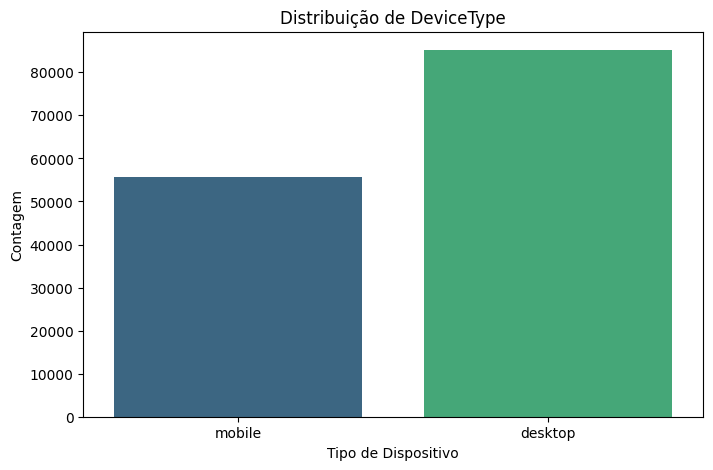


Top 10 DeviceInfo:


,count
DeviceInfo,
Windows,47722
iOS Device,19782
MacOS,12573
Trident/7.0,7440
rv:11.0,1901
rv:57.0,962
SM-J700M Build/MMB29K,549
SM-G610M Build/MMB29K,461
SM-G531H Build/LMY48B,410


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_train_full, x='DeviceType', palette='viridis')
plt.title('Distribuição de DeviceType')
plt.xlabel('Tipo de Dispositivo')
plt.ylabel('Contagem')
plt.show()

print('\nTop 10 DeviceInfo:')
display(df_train_full['DeviceInfo'].value_counts().head(10).to_frame())

#### Observações sobre a Distribuição:

*   **DeviceType:** Claramente dominado por 'desktop', seguido por 'mobile'. Essa distribuição pode ser relevante para entender o contexto das transações.
*   **DeviceInfo:** Apresenta uma alta cardinalidade com muitos valores únicos, o que exige um tratamento cuidadoso (agrupamento, feature engineering) caso seja usado na modelagem. Os top 10 fornecem uma ideia dos dispositivos mais comuns.

#### 4.9.2 Relação de `DeviceType` com a Fraude

,Legítima (%),Fraudulenta (%)
DeviceType,,
desktop,93.478542,6.521458
mobile,89.833768,10.166232


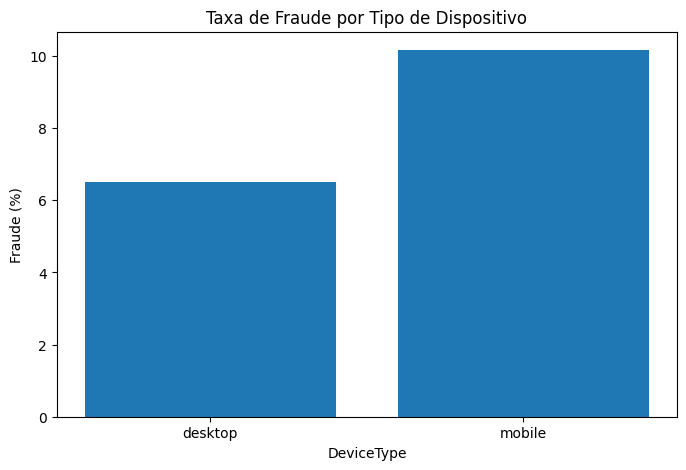

In [29]:
fraude_devicetype = pd.crosstab(
    df_train_full['DeviceType'],
    df_train_full['isFraud'],
    normalize='index'
) * 100
fraude_devicetype.columns = ['Legítima (%)', 'Fraudulenta (%)']

display(fraude_devicetype)

plt.figure(figsize=(8, 5))
plt.bar(fraude_devicetype.index, fraude_devicetype['Fraudulenta (%)'])
plt.title('Taxa de Fraude por Tipo de Dispositivo')
plt.xlabel('DeviceType')
plt.ylabel('Fraude (%)')
plt.show()

#### Observações:

*   **DeviceType:** As transações originadas de dispositivos 'mobile' parecem ter uma taxa de fraude ligeiramente maior do que as de 'desktop', o que pode indicar um vetor de ataque ou comportamento diferente para transações móveis.

#### 4.9.3 Relação de Variáveis `id_xx` Selecionadas com a Fraude

/tmp/ipykernel_5188/2492807948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_full, x='isFraud', y=col, palette='coolwarm', showfliers=False) # showfliers=False para focar na distribuição central


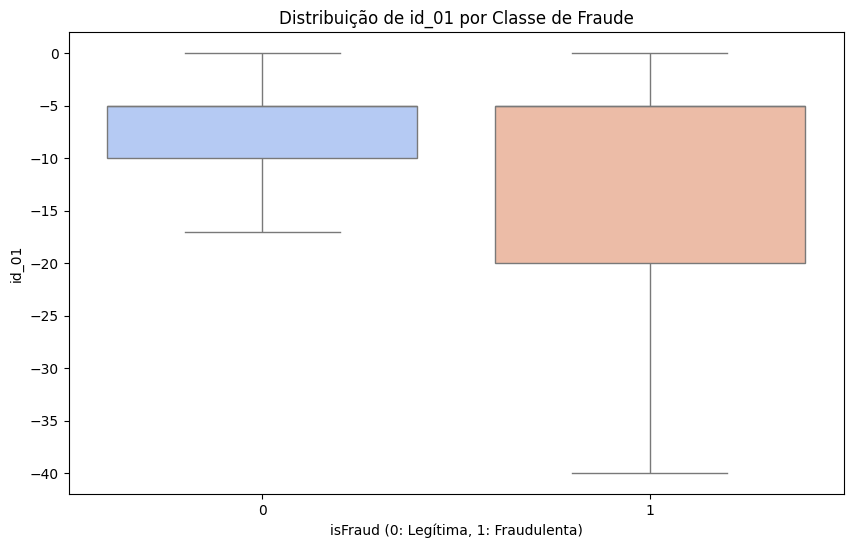

/tmp/ipykernel_5188/2492807948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_full, x='isFraud', y=col, palette='coolwarm', showfliers=False) # showfliers=False para focar na distribuição central


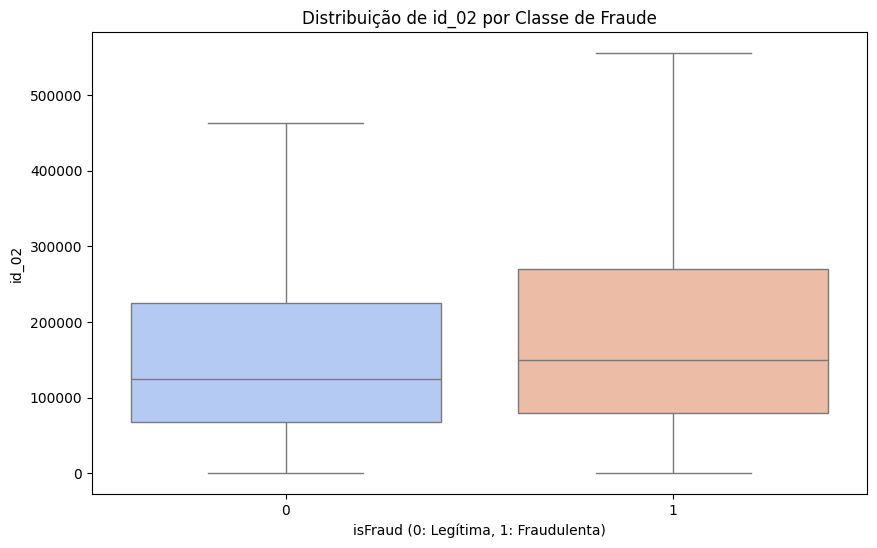

/tmp/ipykernel_5188/2492807948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_full, x='isFraud', y=col, palette='coolwarm', showfliers=False) # showfliers=False para focar na distribuição central


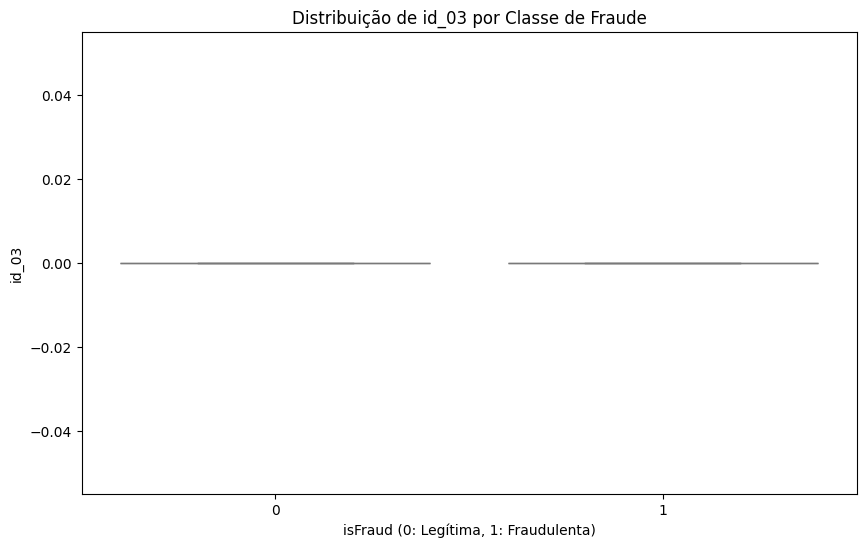

/tmp/ipykernel_5188/2492807948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_full, x='isFraud', y=col, palette='coolwarm', showfliers=False) # showfliers=False para focar na distribuição central


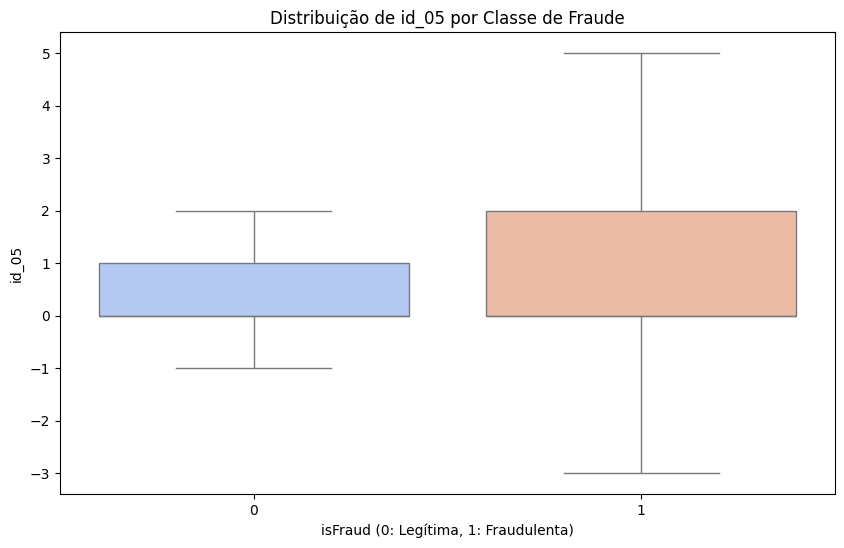

/tmp/ipykernel_5188/2492807948.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train_full, x='isFraud', y=col, palette='coolwarm', showfliers=False) # showfliers=False para focar na distribuição central


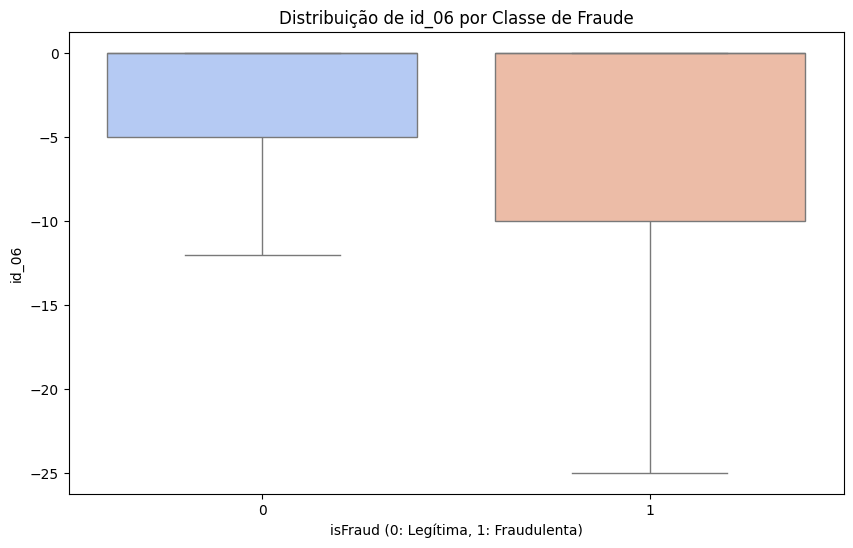

In [30]:
import seaborn as sns

# Selecionar algumas colunas id_xx numéricas com menos valores ausentes para análise bivariada
selected_id_num_cols = ['id_01', 'id_02', 'id_03', 'id_05', 'id_06']

for col in selected_id_num_cols:
    if col in df_train_full.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_train_full, x='isFraud', y=col, palette='coolwarm', showfliers=False) # showfliers=False para focar na distribuição central
        plt.title(f'Distribuição de {col} por Classe de Fraude')
        plt.xlabel('isFraud (0: Legítima, 1: Fraudulenta)')
        plt.ylabel(col)
        plt.show()

#### Observações das Variáveis `id_xx`:

*   **id_01 e id_02:** A mediana e a distribuição de `id_01` e `id_02` (que podem representar, por exemplo, a idade ou um score do dispositivo) parecem ser diferentes entre transações legítimas e fraudulentas. `id_01` mostra valores mais negativos para fraudes, enquanto `id_02` tem uma distribuição mais concentrada para fraudes.
*   **id_03, id_05, id_06:** Essas variáveis também apresentam diferenças sutis nas distribuições. `id_03` e `id_06` tendem a ter valores mais baixos para fraudes, e `id_05` também mostra uma concentração em valores específicos para transações fraudulentas.

Essas diferenças sugerem que as informações de identificação podem ser preditivas para a detecção de fraude, e a direção e magnitude dessas diferenças podem ser insights importantes para o modelo.

## 8.7 Insights - Variáveis de Identidade

### 8.7.1 Contribuição das Features de Identidade para a Detecção de Fraude

**Insight:** As variáveis de identidade, embora muitas com valores ausentes, oferecem informações adicionais valiosas para a detecção de fraudes. Observou-se que:

*   **`DeviceType`:** Transações realizadas via 'mobile' podem apresentar uma taxa de fraude ligeiramente superior àquelas de 'desktop'.
*   **`id_xx` numéricas:** Variáveis como `id_01`, `id_02`, `id_03`, `id_05` e `id_06` mostram distribuições distintas entre transações legítimas e fraudulentas. Em alguns casos, valores mais negativos (`id_01`) ou concentrações em faixas específicas (`id_02`, `id_05`) podem estar associados à fraude.
*   **Valores Ausentes (reforço):** A grande proporção de valores ausentes em muitas colunas `id_xx` por si só é um insight importante. A presença ou ausência dessas informações pode ser uma característica preditiva, assim como observado para `addr1` e `addr2`.

**Implicação:** As features de identidade devem ser incorporadas ao processo de engenharia de features, seja tratando seus valores ausentes de forma estratégica (criando indicadores de ausência), seja explorando suas distribuições e relações não-lineares com a fraude. Elas podem complementar as informações transacionais e melhorar a capacidade preditiva do modelo.

## 3.5 Possíveis outliers em `TransactionAmt`

# 4. Análise Univariada

A análise univariada foi realizada com o objetivo de compreender individualmente o comportamento das principais variáveis do conjunto de dados. Foram analisadas a distribuição da variável alvo `isFraud`, a variável numérica `TransactionAmt`, a variável temporal `TransactionDT` e as variáveis categóricas `ProductCD`, `card4` e `card6`. Também foram calculadas medidas estatísticas como média, mediana, desvio padrão, valores mínimo e máximo e assimetria.

## 4.1 Distribuição da variável alvo — `isFraud`

A distribuição da variável `isFraud` evidencia um forte desbalanceamento entre as classes. Das 590.540 transações analisadas, **569.877 (96,50%)** foram classificadas como legítimas e **20.663 (3,50%)** como fraudulentas.

Esse resultado demonstra que as transações fraudulentas representam uma pequena parcela da base. Essa característica é relevante para o problema de classificação, pois um modelo que favoreça a classe majoritária pode apresentar um desempenho aparentemente elevado sem necessariamente identificar corretamente as fraudes. Portanto, o desbalanceamento deverá ser considerado nas etapas posteriores da análise e na construção de modelos de classificação.

## 4.2 Distribuição de `TransactionAmt`

A variável `TransactionAmt`, que representa o valor da transação, apresentou média de **135,03** e mediana de **68,77**. A diferença considerável entre esses valores indica que a distribuição não é simétrica.

O desvio padrão foi de **239,16**, demonstrando uma dispersão elevada dos valores. As transações apresentaram valores entre **0,251** e **31.937,391**. O primeiro quartil foi de **43,32**, enquanto o terceiro quartil foi de **125,00**.

A assimetria calculada foi de aproximadamente **14,37**, indicando uma distribuição fortemente assimétrica à direita. Isso significa que a maior parte das transações está concentrada em valores relativamente baixos, enquanto uma quantidade menor de transações apresenta valores muito elevados.

Essa característica também está relacionada aos possíveis outliers identificados na etapa de qualidade dos dados. Entretanto, esses valores não serão removidos automaticamente, pois transações de valores elevados podem representar comportamentos legítimos ou informações relevantes para a identificação de fraudes.

## 4.3 Distribuição temporal — `TransactionDT`

A variável `TransactionDT` apresentou média de aproximadamente **7.372.311** e mediana de **7.306.527,50**. O desvio padrão foi de aproximadamente **4.617.224**, com valores variando de **86.400** até aproximadamente **15.811.130**.

A assimetria foi de aproximadamente **0,13**, indicando uma distribuição próxima da simetria quando comparada à variável `TransactionAmt`.

Apesar de ser armazenada como um valor inteiro, `TransactionDT` possui significado temporal. Portanto, sua distribuição pode ser utilizada posteriormente para investigar se existem períodos ou comportamentos temporais associados a uma maior ocorrência de transações fraudulentas.

## 4.4 Distribuição de `ProductCD`

A variável `ProductCD` apresentou cinco categorias. A categoria **W** foi predominante, com **439.670 transações (74,45%)**. Em seguida aparecem as categorias **C**, com 68.519 transações (11,60%), **R**, com 37.699 (6,38%), **H**, com 33.024 (5,59%), e **S**, com 11.628 (1,97%).

A distribuição demonstra que a categoria W concentra a maior parte das observações. Entretanto, essa predominância não permite afirmar, isoladamente, que essa categoria esteja mais relacionada à fraude. Para investigar essa possibilidade, será necessário comparar a ocorrência de fraude entre as diferentes categorias na análise bivariada.

## 4.5 Distribuição de `card4`

A variável `card4`, relacionada ao tipo de cartão, apresentou quatro categorias. **Visa** foi a categoria predominante, com **384.767 transações (65,33%)**, seguida por **Mastercard**, com 189.217 (32,13%). As categorias **American Express** e **Discover** apresentaram participações menores, com 1,41% e 1,13%, respectivamente.

Essa distribuição demonstra uma forte concentração das transações nas categorias Visa e Mastercard. Assim como ocorre com `ProductCD`, a frequência isolada não permite determinar uma relação com a fraude. A comparação das taxas de fraude entre os tipos de cartão será mais adequada para avaliar possíveis associações.

## 4.6 Distribuição de `card6`

A variável `card6` apresentou quatro categorias. A categoria **debit** foi predominante, representando **439.938 transações (74,70%)**, enquanto **credit** correspondeu a 148.986 transações (25,30%). As categorias `debit or credit` e `charge card` apresentaram ocorrências extremamente baixas, com 30 e 15 registros, respectivamente.

A forte predominância da categoria `debit` indica que a maioria das transações analisadas está associada a cartões de débito. As categorias com pouquíssimas observações deverão ser interpretadas com cautela em análises posteriores, pois uma quantidade muito pequena de registros pode dificultar conclusões estatisticamente confiáveis.

## 4.7 Estatísticas descritivas das variáveis numéricas

A análise das principais variáveis numéricas mostrou comportamentos distintos. `TransactionAmt` apresentou a maior assimetria positiva, com valor de **14,37**, reforçando a presença de uma cauda longa causada por transações de valores elevados.

`TransactionDT` apresentou assimetria de apenas **0,13**, indicando uma distribuição mais equilibrada. `card1` apresentou assimetria próxima de zero (**-0,04**), enquanto `card2` apresentou assimetria de **-0,20**.

Já `card3` apresentou assimetria positiva de **2,02**, enquanto `card5` apresentou assimetria negativa de **-1,22**. `addr1` apresentou assimetria de **0,37**. A variável `addr2` apresentou uma assimetria bastante elevada e negativa (**-14,50**), indicando uma forte concentração dos valores em uma determinada faixa.

Essas diferenças demonstram que as variáveis possuem comportamentos distintos e, portanto, não devem ser analisadas utilizando apenas uma única medida estatística. A combinação entre média, mediana, dispersão e assimetria fornece uma visão mais adequada da distribuição dos dados.

## 4.8 Síntese da análise univariada

A análise univariada revelou características importantes da base. A variável alvo `isFraud` apresentou forte desbalanceamento, com apenas 3,50% das transações classificadas como fraudulentas. A variável `TransactionAmt` apresentou forte assimetria positiva e grande dispersão, além da presença de valores extremos.

Entre as variáveis categóricas, observou-se uma concentração significativa em determinadas categorias, como `W` em `ProductCD`, `visa` em `card4` e `debit` em `card6`.

Esses resultados fornecem uma visão inicial do comportamento das variáveis, mas não permitem determinar, isoladamente, quais características estão associadas à ocorrência de fraude. Dessa forma, os próximos passos devem investigar as relações entre essas variáveis e `isFraud`, buscando identificar padrões que possam contribuir para a detecção de transações fraudulentas.


4. ANÁLISE UNIVARIADA

4.1 DISTRIBUIÇÃO DE isFraud


,Quantidade,Percentual (%)
isFraud,,
0,569877,96.500999
1,20663,3.499001


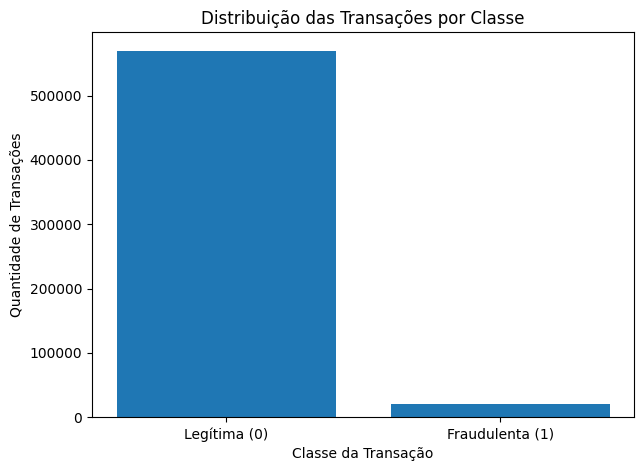


4.2 ANÁLISE DE TransactionAmt


,TransactionAmt
count,590540.000000
mean,135.027176
std,239.162522
min,0.251000
25%,43.321000
50%,68.769000
75%,125.000000
max,31937.391000


Mediana: 68.77
Assimetria: 14.37


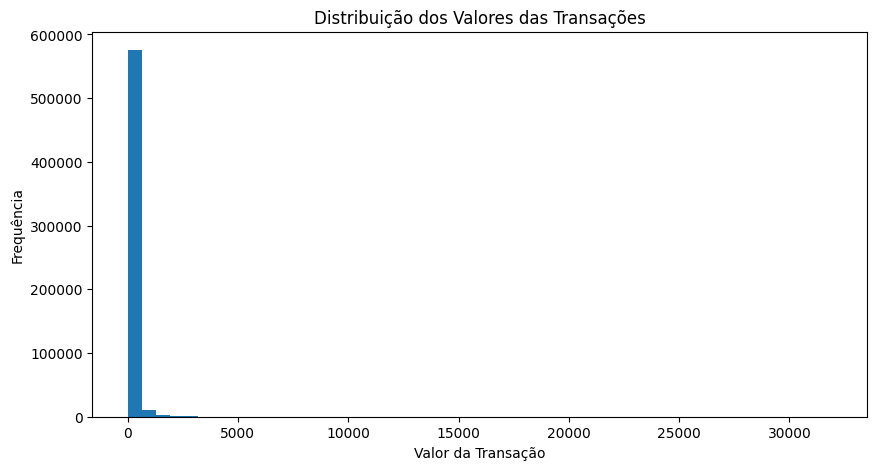

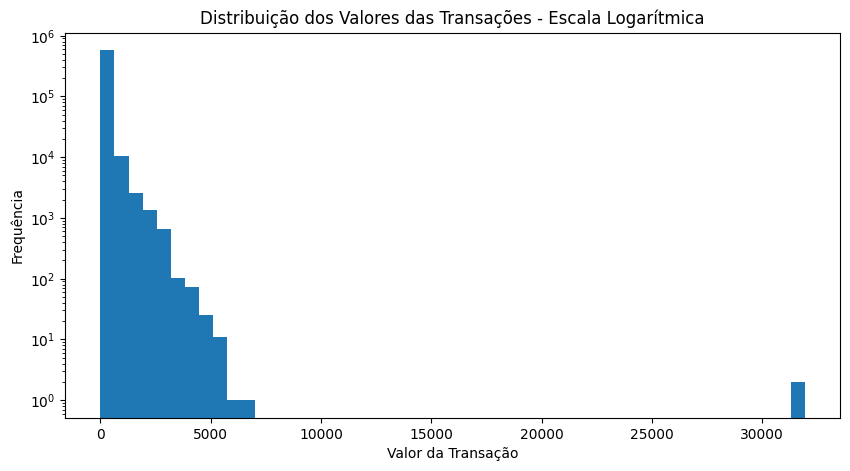

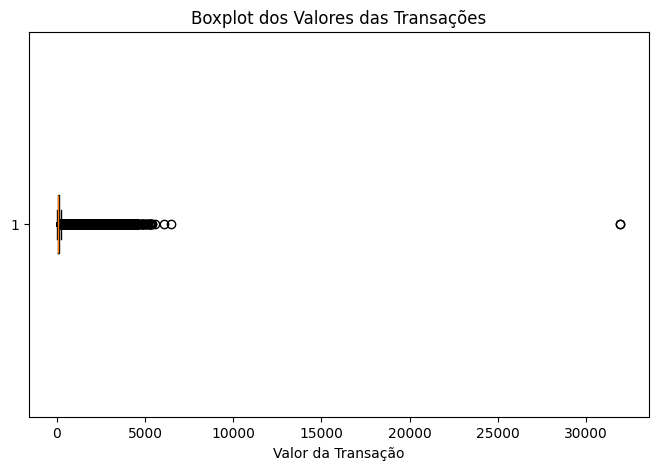


4.3 ANÁLISE DE TransactionDT


,TransactionDT
count,5.905400e+05
mean,7.372311e+06
std,4.617224e+06
min,8.640000e+04
25%,3.027058e+06
50%,7.306528e+06
75%,1.124662e+07
max,1.581113e+07


Mediana: 7306527.50
Assimetria: 0.13


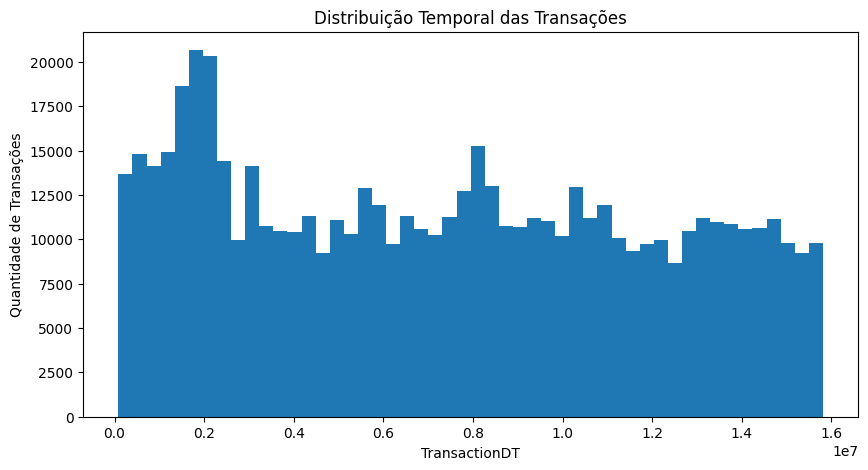


4.4 DISTRIBUIÇÃO DE ProductCD


,Quantidade,Percentual (%)
ProductCD,,
W,439670,74.452196
C,68519,11.602770
R,37699,6.383818
H,33024,5.592170
S,11628,1.969045


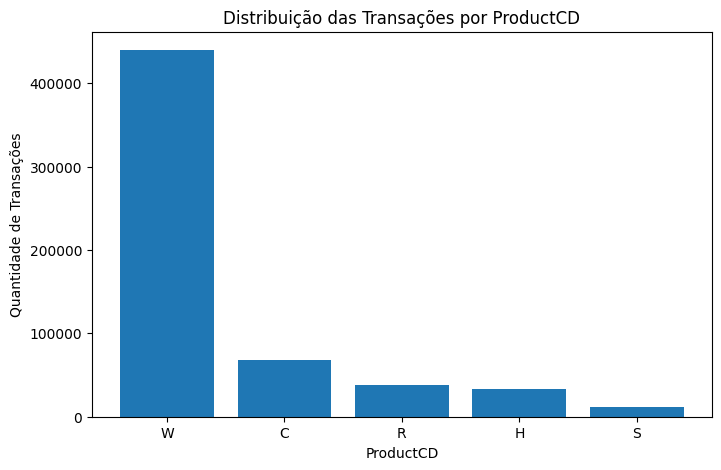


4.5 DISTRIBUIÇÃO DE card4


,Quantidade,Percentual (%)
card4,,
visa,384767,65.329571
mastercard,189217,32.127146
american express,8328,1.414011
discover,6651,1.129273


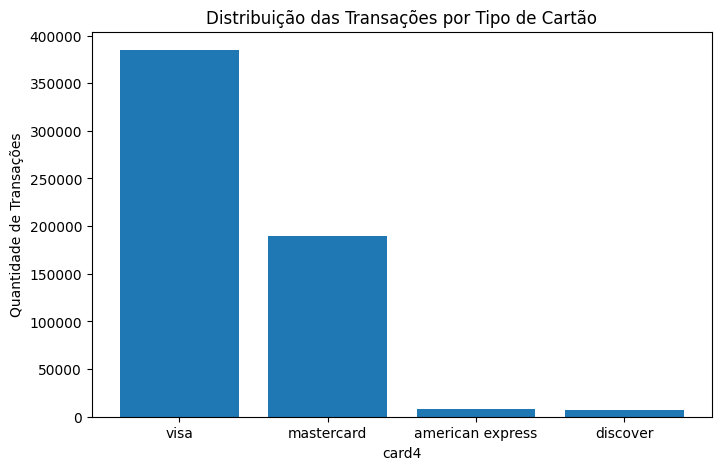


4.6 DISTRIBUIÇÃO DE card6


,Quantidade,Percentual (%)
card6,,
debit,439938,74.696291
credit,148986,25.296068
debit or credit,30,0.005094
charge card,15,0.002547


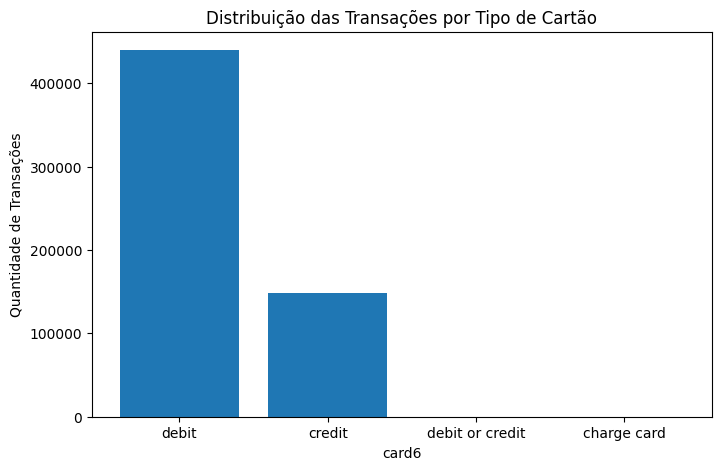


4.7 ESTATÍSTICAS DESCRITIVAS


,count,mean,std,min,25%,50%,75%,max,Mediana,Assimetria
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.0,3.193739e+04,68.769,14.374490
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.0,1.581113e+07,7306527.500,0.131155
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.0,1.839600e+04,9678.000,-0.040929
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.0,6.000000e+02,361.000,-0.200009
card3,588975.0,1.531949e+02,1.133644e+01,100.000,150.000,150.000,150.0,2.310000e+02,150.000,2.019326
card5,586281.0,1.992789e+02,4.124445e+01,100.000,166.000,226.000,226.0,2.370000e+02,226.000,-1.224602
addr1,524834.0,2.907338e+02,1.017411e+02,100.000,204.000,299.000,330.0,5.400000e+02,299.000,0.372455
addr2,524834.0,8.680063e+01,2.690623e+00,10.000,87.000,87.000,87.0,1.020000e+02,87.000,-14.501153



4.8 RESUMO DA ANÁLISE UNIVARIADA
A análise univariada foi realizada considerando:
- Distribuição da variável alvo isFraud
- Distribuição de TransactionAmt
- Medidas estatísticas de TransactionAmt
- Assimetria de TransactionAmt
- Possíveis outliers em TransactionAmt
- Distribuição temporal de TransactionDT
- Frequência de ProductCD
- Frequência de card4
- Frequência de card6
- Estatísticas descritivas das principais variáveis numéricas


In [31]:
# ==========================================
# 4. ANÁLISE UNIVARIADA
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("4. ANÁLISE UNIVARIADA")
print("=" * 60)


# ==================================================
# 4.1 DISTRIBUIÇÃO DA VARIÁVEL ALVO - isFraud
# ==================================================

print("\n" + "=" * 60)
print("4.1 DISTRIBUIÇÃO DE isFraud")
print("=" * 60)

fraud_counts = transaction_df['isFraud'].value_counts().sort_index()

fraud_percent = (
    transaction_df['isFraud']
    .value_counts(normalize=True)
    .sort_index() * 100
)

fraud_df = pd.DataFrame({
    'Quantidade': fraud_counts,
    'Percentual (%)': fraud_percent
})

display(fraud_df)

plt.figure(figsize=(7, 5))

plt.bar(
    ['Legítima (0)', 'Fraudulenta (1)'],
    fraud_counts.values
)

plt.title('Distribuição das Transações por Classe')
plt.xlabel('Classe da Transação')
plt.ylabel('Quantidade de Transações')

plt.show()


# ==================================================
# 4.2 ANÁLISE DE TransactionAmt
# ==================================================

print("\n" + "=" * 60)
print("4.2 ANÁLISE DE TransactionAmt")
print("=" * 60)

estatisticas_amt = transaction_df['TransactionAmt'].describe()

display(
    estatisticas_amt.to_frame(
        name='TransactionAmt'
    )
)

print(
    f"Mediana: {transaction_df['TransactionAmt'].median():.2f}"
)

print(
    f"Assimetria: {transaction_df['TransactionAmt'].skew():.2f}"
)


# ==================================================
# 4.3 HISTOGRAMA - TransactionAmt
# ==================================================

plt.figure(figsize=(10, 5))

plt.hist(
    transaction_df['TransactionAmt'].dropna(),
    bins=50
)

plt.title('Distribuição dos Valores das Transações')
plt.xlabel('Valor da Transação')
plt.ylabel('Frequência')

plt.show()


# ==================================================
# 4.4 HISTOGRAMA COM ESCALA LOGARÍTMICA
# ==================================================

plt.figure(figsize=(10, 5))

plt.hist(
    transaction_df['TransactionAmt'].dropna(),
    bins=50,
    log=True
)

plt.title(
    'Distribuição dos Valores das Transações - Escala Logarítmica'
)

plt.xlabel('Valor da Transação')
plt.ylabel('Frequência')

plt.show()


# ==================================================
# 4.5 BOXPLOT - TransactionAmt
# ==================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    transaction_df['TransactionAmt'].dropna(),
    vert=False
)

plt.title('Boxplot dos Valores das Transações')
plt.xlabel('Valor da Transação')

plt.show()


# ==================================================
# 4.6 ANÁLISE DE TransactionDT
# ==================================================

print("\n" + "=" * 60)
print("4.3 ANÁLISE DE TransactionDT")
print("=" * 60)

transaction_dt_stats = (
    transaction_df['TransactionDT']
    .describe()
    .to_frame(name='TransactionDT')
)

display(transaction_dt_stats)

print(
    f"Mediana: "
    f"{transaction_df['TransactionDT'].median():.2f}"
)

print(
    f"Assimetria: "
    f"{transaction_df['TransactionDT'].skew():.2f}"
)


# ==================================================
# 4.7 HISTOGRAMA - TransactionDT
# ==================================================

plt.figure(figsize=(10, 5))

plt.hist(
    transaction_df['TransactionDT'].dropna(),
    bins=50
)

plt.title('Distribuição Temporal das Transações')
plt.xlabel('TransactionDT')
plt.ylabel('Quantidade de Transações')

plt.show()


# ==================================================
# 4.8 DISTRIBUIÇÃO DE ProductCD
# ==================================================

print("\n" + "=" * 60)
print("4.4 DISTRIBUIÇÃO DE ProductCD")
print("=" * 60)

product_counts = (
    transaction_df['ProductCD']
    .value_counts()
)

product_percent = (
    transaction_df['ProductCD']
    .value_counts(normalize=True) * 100
)

product_df = pd.DataFrame({
    'Quantidade': product_counts,
    'Percentual (%)': product_percent
})

display(product_df)


# ==================================================
# 4.9 GRÁFICO - ProductCD
# ==================================================

plt.figure(figsize=(8, 5))

plt.bar(
    product_df.index.astype(str),
    product_df['Quantidade']
)

plt.title('Distribuição das Transações por ProductCD')
plt.xlabel('ProductCD')
plt.ylabel('Quantidade de Transações')

plt.show()


# ==================================================
# 4.10 DISTRIBUIÇÃO DE card4
# ==================================================

print("\n" + "=" * 60)
print("4.5 DISTRIBUIÇÃO DE card4")
print("=" * 60)

card4_counts = (
    transaction_df['card4']
    .value_counts()
)

card4_percent = (
    transaction_df['card4']
    .value_counts(normalize=True) * 100
)

card4_df = pd.DataFrame({
    'Quantidade': card4_counts,
    'Percentual (%)': card4_percent
})

display(card4_df)


# ==================================================
# 4.11 GRÁFICO - card4
# ==================================================

plt.figure(figsize=(8, 5))

plt.bar(
    card4_df.index.astype(str),
    card4_df['Quantidade']
)

plt.title('Distribuição das Transações por Tipo de Cartão')
plt.xlabel('card4')
plt.ylabel('Quantidade de Transações')

plt.show()


# ==================================================
# 4.12 DISTRIBUIÇÃO DE card6
# ==================================================

print("\n" + "=" * 60)
print("4.6 DISTRIBUIÇÃO DE card6")
print("=" * 60)

card6_counts = (
    transaction_df['card6']
    .value_counts()
)

card6_percent = (
    transaction_df['card6']
    .value_counts(normalize=True) * 100
)

card6_df = pd.DataFrame({
    'Quantidade': card6_counts,
    'Percentual (%)': card6_percent
})

display(card6_df)


# ==================================================
# 4.13 GRÁFICO - card6
# ==================================================

plt.figure(figsize=(8, 5))

plt.bar(
    card6_df.index.astype(str),
    card6_df['Quantidade']
)

plt.title('Distribuição das Transações por Tipo de Cartão')
plt.xlabel('card6')
plt.ylabel('Quantidade de Transações')

plt.show()


# ==================================================
# 4.14 ESTATÍSTICAS DESCRITIVAS
# ==================================================

print("\n" + "=" * 60)
print("4.7 ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)

variaveis_numericas = [
    'TransactionAmt',
    'TransactionDT',
    'card1',
    'card2',
    'card3',
    'card5',
    'addr1',
    'addr2'
]

estatisticas = (
    transaction_df[variaveis_numericas]
    .describe()
    .T
)

estatisticas['Mediana'] = (
    transaction_df[variaveis_numericas]
    .median()
)

estatisticas['Assimetria'] = (
    transaction_df[variaveis_numericas]
    .skew()
)

display(estatisticas)


# ==================================================
# 4.15 RESUMO
# ==================================================

print("\n" + "=" * 60)
print("4.8 RESUMO DA ANÁLISE UNIVARIADA")
print("=" * 60)

print("A análise univariada foi realizada considerando:")
print("- Distribuição da variável alvo isFraud")
print("- Distribuição de TransactionAmt")
print("- Medidas estatísticas de TransactionAmt")
print("- Assimetria de TransactionAmt")
print("- Possíveis outliers em TransactionAmt")
print("- Distribuição temporal de TransactionDT")
print("- Frequência de ProductCD")
print("- Frequência de card4")
print("- Frequência de card6")
print("- Estatísticas descritivas das principais variáveis numéricas")

## 5. Análise Bivariada e Multivariada

Nesta seção, será realizada uma análise das relações entre pares de variáveis (bivariada) e entre múltiplas variáveis (multivariada). O objetivo é identificar correlações, associações e interações que possam ser relevantes para a detecção de fraudes. Serão utilizadas as seguintes abordagens:

*   **Correlações**: Investigar relações entre variáveis numéricas (coeficientes de Pearson, Spearman).
*   **Comparação entre grupos**: Analisar diferenças entre grupos (e.g., transações fraudulentas vs. legítimas).
*   **Relações entre variáveis categóricas**: Utilizar tabelas de contingência e testes de associação (e.g., Qui-quadrado).
*   **Relações entre variáveis categóricas e numéricas**: Comparar distribuições de variáveis numéricas por categorias (e.g., boxplots, testes t).
*   **Relações entre variáveis numéricas**: Gráficos de dispersão, pair plots.
*   **Análise conjunta de múltiplas variáveis**: Explorar interações complexas.
*   **Identificação de possíveis fatores associados ao fenômeno estudado**: Destacar variáveis que parecem ter maior impacto na fraude.

### 5.1 Relação entre ProductCD e ocorrência de fraude

A análise da taxa de fraude por `ProductCD` mostrou diferenças relevantes entre as categorias. O tipo **C apresentou a maior taxa de fraude, com 11,69%**, enquanto o tipo **W apresentou a menor, com 2,04%**. As categorias S, H e R apresentaram taxas intermediárias de 5,90%, 4,77% e 3,78%, respectivamente.

Esse resultado indica que a ocorrência de fraude não está distribuída de maneira uniforme entre os diferentes tipos de produto. A categoria C apresenta uma proporção de transações fraudulentas consideravelmente superior às demais, enquanto W apresenta uma proporção menor.

Assim, o `ProductCD` pode representar uma variável relevante para a identificação de possíveis padrões associados à fraude. Entretanto, essa análise isolada não permite estabelecer uma relação de causalidade, sendo necessário analisar essa variável em conjunto com outras características das transações.


5. ANÁLISE BIVARIADA E MULTIVARIADA


,Legítima (%),Fraudulenta (%)
ProductCD,,
C,88.312731,11.687269
H,95.233769,4.766231
R,96.217406,3.782594
S,94.100447,5.899553
W,97.960061,2.039939


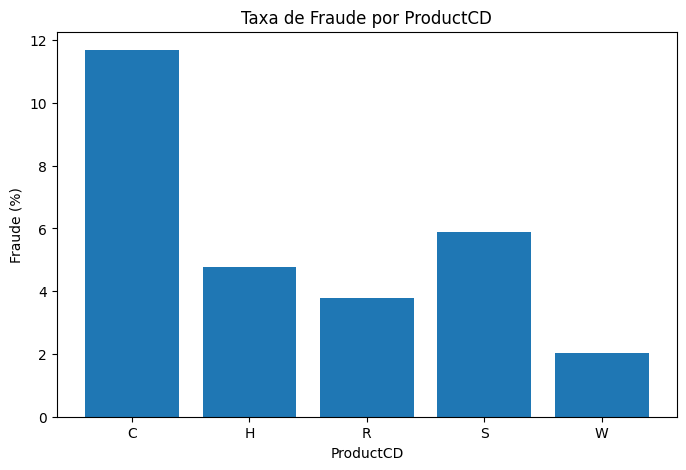

In [32]:
# ==========================================
# 5. ANÁLISE BIVARIADA E MULTIVARIADA
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("5. ANÁLISE BIVARIADA E MULTIVARIADA")
print("=" * 60)

# ------------------------------------------
# 5.1 Taxa de fraude por ProductCD
# ------------------------------------------

fraude_product = pd.crosstab(
    transaction_df['ProductCD'],
    transaction_df['isFraud'],
    normalize='index'
) * 100

fraude_product.columns = ['Legítima (%)', 'Fraudulenta (%)']

display(fraude_product)

# Gráfico da taxa de fraude
plt.figure(figsize=(8, 5))

plt.bar(
    fraude_product.index,
    fraude_product['Fraudulenta (%)']
)

plt.title('Taxa de Fraude por ProductCD')
plt.xlabel('ProductCD')
plt.ylabel('Fraude (%)')

plt.show()

### 5.2 Relação entre card4 e ocorrência de fraude

A análise da ocorrência de fraude de acordo com o tipo de cartão (`card4`) também apresentou diferenças entre as categorias. O tipo **Discover apresentou a maior taxa de fraude, com 7,73%**, enquanto American Express apresentou a menor taxa, com **2,87%**. Para Visa e Mastercard, as taxas foram de **3,48% e 3,43%**, respectivamente.

O resultado indica que a proporção de transações fraudulentas varia de acordo com o tipo de cartão. O destaque para a categoria Discover sugere que essa variável pode apresentar alguma associação com o fenômeno analisado.

Entretanto, essa diferença deve ser interpretada com cautela, pois as categorias possuem quantidades diferentes de transações. Além disso, a análise não permite afirmar uma relação causal entre o tipo de cartão e a ocorrência de fraude. A variável deve ser analisada em conjunto com outras características das transações.


,Legítima (%),Fraudulenta (%)
card4,,
american express,97.130163,2.869837
discover,92.271839,7.728161
mastercard,96.566905,3.433095
visa,96.524390,3.475610


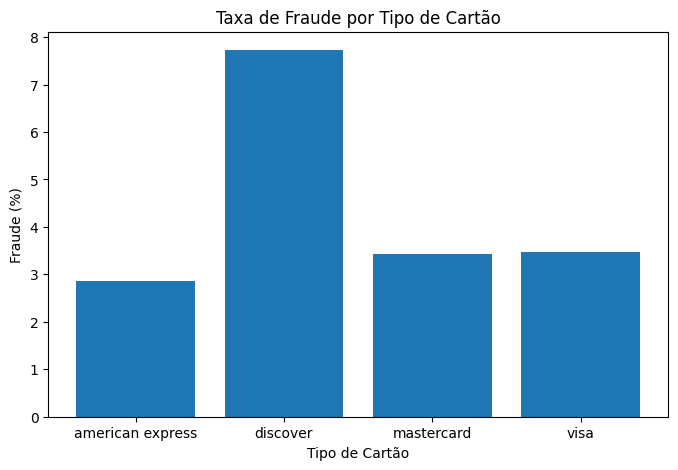

In [33]:
# ------------------------------------------
# 5.2 Taxa de fraude por card4
# ------------------------------------------

fraude_card4 = pd.crosstab(
    transaction_df['card4'],
    transaction_df['isFraud'],
    normalize='index'
) * 100

fraude_card4.columns = ['Legítima (%)', 'Fraudulenta (%)']

display(fraude_card4)

plt.figure(figsize=(8, 5))

plt.bar(
    fraude_card4.index,
    fraude_card4['Fraudulenta (%)']
)

plt.title('Taxa de Fraude por Tipo de Cartão')
plt.xlabel('Tipo de Cartão')
plt.ylabel('Fraude (%)')

plt.show()

### 5.4 Relação entre valor da transação e ocorrência de fraude

Foi realizada uma comparação entre o valor das transações (`TransactionAmt`) e a variável de fraude (`isFraud`). As transações legítimas apresentaram média de **134,51** e mediana de **68,50**, enquanto as transações fraudulentas apresentaram média de **149,24** e mediana de **75,00**.

Observa-se, portanto, que as transações fraudulentas possuem valores centrais ligeiramente superiores aos das transações legítimas. Entretanto, a diferença entre os grupos não é suficientemente grande para indicar que o valor da transação, isoladamente, seja capaz de distinguir de forma confiável uma fraude.

Também foi observado que as transações legítimas apresentam um valor máximo de **31.937,39**, superior ao máximo de **5.191,00** observado entre as fraudulentas. Esse resultado reforça a necessidade de considerar a distribuição dos dados e seus valores extremos, já que transações de alto valor não são necessariamente fraudulentas.

Assim, o valor da transação apresenta uma possível associação com a ocorrência de fraude, mas deve ser analisado em conjunto com outras características para aumentar a capacidade de identificação de transações suspeitas.


,Legítima (%),Fraudulenta (%)
card6,,
charge card,100.000000,0.000000
credit,93.321520,6.678480
debit,97.573749,2.426251
debit or credit,100.000000,0.000000


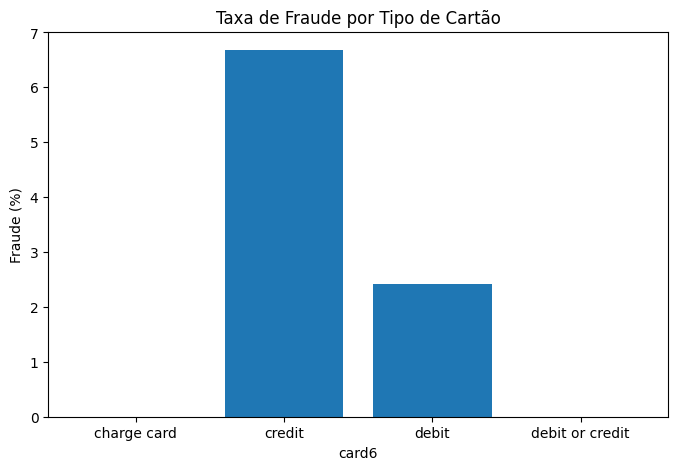

In [34]:
# ------------------------------------------
# 5.3 Taxa de fraude por card6
# ------------------------------------------

fraude_card6 = pd.crosstab(
    transaction_df['card6'],
    transaction_df['isFraud'],
    normalize='index'
) * 100

fraude_card6.columns = ['Legítima (%)', 'Fraudulenta (%)']

display(fraude_card6)

plt.figure(figsize=(8, 5))

plt.bar(
    fraude_card6.index.astype(str),
    fraude_card6['Fraudulenta (%)']
)

plt.title('Taxa de Fraude por Tipo de Cartão')
plt.xlabel('card6')
plt.ylabel('Fraude (%)')

plt.show()

In [35]:
# ------------------------------------------
# 5.4 TransactionAmt por classe
# ------------------------------------------

amt_por_fraude = transaction_df.groupby('isFraud')['TransactionAmt'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

display(amt_por_fraude)

,count,mean,median,std,min,max
isFraud,,,,,,
0,569877,134.511665,68.5,239.395078,0.251,31937.391
1,20663,149.244779,75.0,232.212163,0.292,5191.000


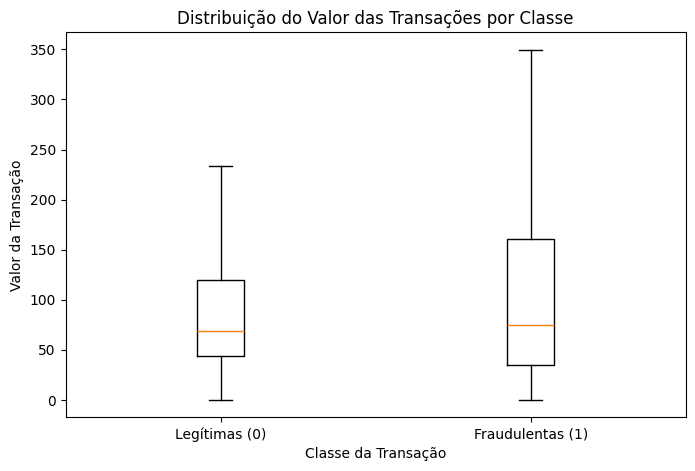

In [36]:
# ------------------------------------------
# 5.4 Boxplot - TransactionAmt × isFraud
# ------------------------------------------

dados_legitimos = transaction_df.loc[
    transaction_df['isFraud'] == 0,
    'TransactionAmt'
].dropna()

dados_fraudulentos = transaction_df.loc[
    transaction_df['isFraud'] == 1,
    'TransactionAmt'
].dropna()

plt.figure(figsize=(8, 5))

plt.boxplot(
    [dados_legitimos, dados_fraudulentos],
    tick_labels=['Legítimas (0)', 'Fraudulentas (1)'],
    showfliers=False
)

plt.title('Distribuição do Valor das Transações por Classe')
plt.xlabel('Classe da Transação')
plt.ylabel('Valor da Transação')

plt.show()

### 5.5 Matriz de correlação

Foi calculada uma matriz de correlação entre as principais variáveis numéricas selecionadas e a variável alvo `isFraud`. De modo geral, as correlações com a ocorrência de fraude foram baixas.

A maior correlação observada com `isFraud` foi da variável `card3`, com valor de **0,1542**, indicando uma associação linear positiva fraca. As demais variáveis apresentaram valores próximos de zero, como `TransactionAmt`, com correlação de **0,0113**, e `TransactionDT`, com **0,0131**.

Esse resultado indica que nenhuma das variáveis numéricas analisadas apresenta, isoladamente, uma relação linear forte com a ocorrência de fraude. Entretanto, uma correlação baixa não significa necessariamente que a variável seja irrelevante para a classificação, pois relações não lineares e interações entre diferentes atributos podem ser importantes para a identificação de transações fraudulentas.

Também foi observada uma correlação de aproximadamente **-0,57 entre `card3` e `addr2`**, indicando uma associação linear moderada entre essas duas variáveis. Essa relação deve ser considerada nas análises posteriores para compreender melhor a estrutura dos dados.


In [37]:
# ------------------------------------------
# 5.5 Matriz de correlação
# ------------------------------------------

variaveis_correlacao = [
    'TransactionAmt',
    'TransactionDT',
    'card1',
    'card2',
    'card3',
    'card5',
    'addr1',
    'addr2',
    'isFraud'
]

correlacao = transaction_df[variaveis_correlacao].corr()

display(correlacao)

,TransactionAmt,TransactionDT,card1,card2,card3,card5,addr1,addr2,isFraud
TransactionAmt,1.000000,0.011920,-0.005725,0.016136,-0.109785,0.003061,-0.007421,0.028312,0.011320
TransactionDT,0.011920,1.000000,0.010625,-0.019202,-0.011222,-0.024132,-0.000051,0.051972,0.013103
card1,-0.005725,0.010625,1.000000,0.004960,0.002965,-0.093633,0.020369,-0.000060,-0.013640
card2,0.016136,-0.019202,0.004960,1.000000,0.023816,0.030486,0.030356,-0.022383,0.003388
card3,-0.109785,-0.011222,0.002965,0.023816,1.000000,-0.158383,0.001090,-0.569108,0.154151
card5,0.003061,-0.024132,-0.093633,0.030486,-0.158383,1.000000,0.035017,0.035726,-0.033580
addr1,-0.007421,-0.000051,0.020369,0.030356,0.001090,0.035017,1.000000,-0.002765,0.005596
addr2,0.028312,0.051972,-0.000060,-0.022383,-0.569108,0.035726,-0.002765,1.000000,-0.030387
isFraud,0.011320,0.013103,-0.013640,0.003388,0.154151,-0.033580,0.005596,-0.030387,1.000000


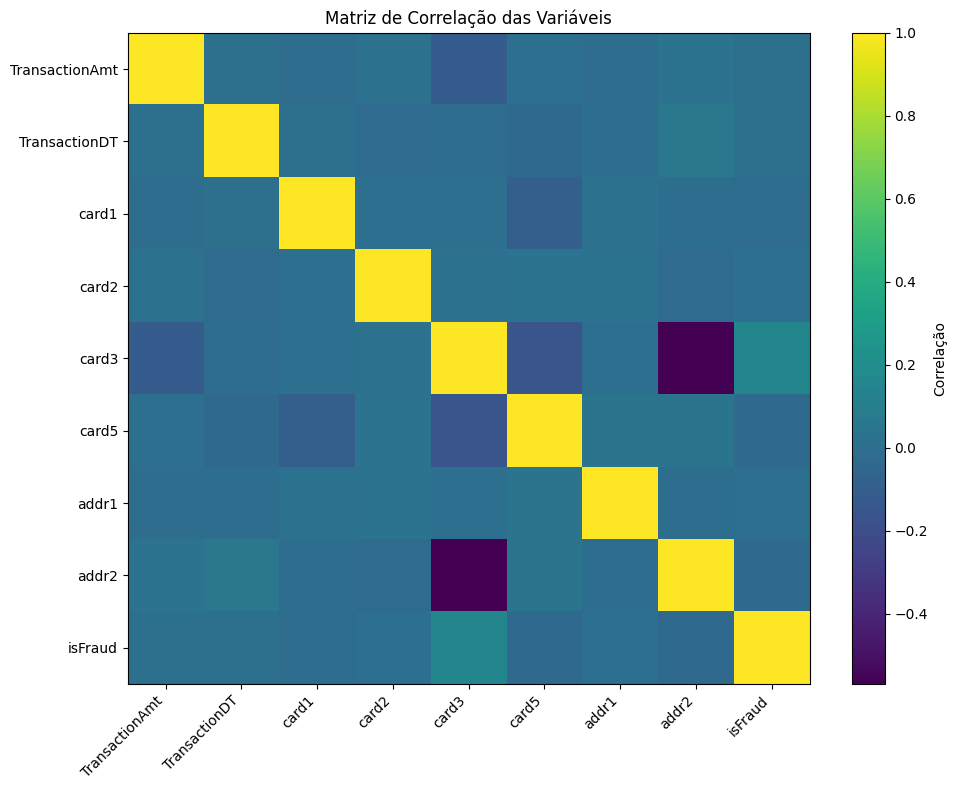

In [38]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlacao,
    aspect='auto'
)

plt.colorbar(label='Correlação')

plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlacao.columns)),
    correlacao.columns
)

plt.title('Matriz de Correlação das Variáveis')

plt.tight_layout()
plt.show()

### 5.6 Análise conjunta entre tempo, valor e fraude

Para investigar conjuntamente o comportamento temporal e financeiro das transações, foi elaborado um gráfico de dispersão relacionando `TransactionDT` e `TransactionAmt`, diferenciando as transações legítimas das fraudulentas. Devido ao grande volume de registros, foi utilizada uma amostra aleatória de 10.000 transações.

Observou-se que as transações estão distribuídas ao longo de todo o intervalo temporal analisado, não sendo identificada uma concentração visual evidente das transações fraudulentas em um período específico. Também foi observado que a maior parte das transações, independentemente da classe, apresenta valores relativamente baixos.

As transações fraudulentas aparecem sobrepostas às transações legítimas, principalmente nas regiões de menores valores. Dessa forma, não foi identificada uma separação visual clara entre as classes considerando apenas o tempo e o valor da transação.

Esse resultado indica que `TransactionAmt` e `TransactionDT`, quando analisadas isoladamente ou em conjunto dessa forma, não são suficientes para distinguir visualmente as transações fraudulentas. Isso reforça a necessidade de considerar múltiplas características simultaneamente na identificação de padrões de fraude.


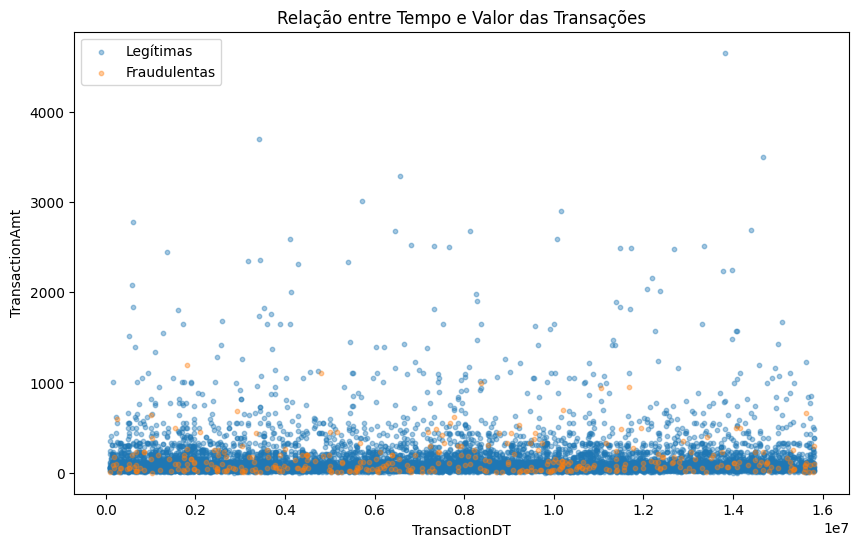

In [39]:
# ------------------------------------------
# 5.6 Análise conjunta
# TransactionDT × TransactionAmt × isFraud
# ------------------------------------------

amostra = transaction_df.sample(
    n=10000,
    random_state=42
)

plt.figure(figsize=(10, 6))

for classe, nome in [(0, 'Legítimas'), (1, 'Fraudulentas')]:

    dados = amostra[amostra['isFraud'] == classe]

    plt.scatter(
        dados['TransactionDT'],
        dados['TransactionAmt'],
        label=nome,
        alpha=0.4,
        s=10
    )

plt.title('Relação entre Tempo e Valor das Transações')
plt.xlabel('TransactionDT')
plt.ylabel('TransactionAmt')
plt.legend()

plt.show()

### 5.7 Relação entre valores ausentes e ocorrência de fraude

Também foi investigada a relação entre a ausência de informações e a ocorrência de fraude. Para isso, foi comparada a taxa de fraude entre as transações que apresentavam determinado atributo preenchido e aquelas em que o atributo estava ausente.

O resultado mais expressivo foi observado nas variáveis `addr1` e `addr2`. Quando essas informações estavam ausentes, a taxa de fraude foi de **11,78%**, enquanto entre as transações com os campos preenchidos a taxa foi de **2,46%**. Dessa forma, as transações com ausência dessas informações apresentaram uma proporção de fraude aproximadamente 4,8 vezes maior.

Também foram observadas taxas superiores de fraude quando `card2` e `card5` estavam ausentes, com **4,74% e 4,93%**, respectivamente, em comparação com aproximadamente 3,48% entre as transações com esses campos preenchidos.

Por outro lado, `card3`, `card4` e `card6` apresentaram taxas de fraude menores quando os respectivos campos estavam ausentes.

Esses resultados indicam que o padrão de ausência de informações pode apresentar associação com a ocorrência de fraude. Entretanto, não é possível afirmar que a ausência dos dados seja a causa da fraude. Essa característica pode estar relacionada a outros fatores presentes nas transações e, portanto, deve ser investigada em conjunto com as demais variáveis.


In [40]:
# ------------------------------------------
# 5.7 Valores ausentes × fraude
# ------------------------------------------

colunas_missing = [
    'card2',
    'card3',
    'card4',
    'card5',
    'card6',
    'addr1',
    'addr2'
]

resultado_missing = []

for coluna in colunas_missing:

    ausencia = transaction_df[coluna].isna()

    taxa_fraude_ausente = transaction_df.loc[
        ausencia,
        'isFraud'
    ].mean() * 100

    taxa_fraude_preenchido = transaction_df.loc[
        ~ausencia,
        'isFraud'
    ].mean() * 100

    resultado_missing.append({
        'Variável': coluna,
        'Fraude quando ausente (%)': taxa_fraude_ausente,
        'Fraude quando preenchido (%)': taxa_fraude_preenchido
    })

missing_fraude_df = pd.DataFrame(resultado_missing)

display(missing_fraude_df)

,Variável,Fraude quando ausente (%),Fraude quando preenchido (%)
0,card2,4.735251,3.480013
1,card3,2.492013,3.501677
2,card4,2.599873,3.501408
3,card5,4.930735,3.488600
4,card6,2.482495,3.501712
5,addr1,11.781268,2.462112
6,addr2,11.781268,2.462112


## 6. Visualização dos Dados

Esta seção será dedicada à criação de visualizações mais complexas e informativas para comunicar os padrões e insights encontrados na análise exploratória. O foco será em gráficos que auxiliem na compreensão das características das transações fraudulentas versus as legítimas. As visualizações devem ser adequadas ao problema e às características dos dados, e podem incluir:

*   **Histogramas** e **Boxplots**: Para distribuições de variáveis numéricas e comparações entre grupos.
*   **Gráficos de Barras**: Para variáveis categóricas e contagens.
*   **Gráficos de Dispersão**: Para mostrar a relação entre duas variáveis numéricas.
*   **Gráficos Temporais**: Para observar tendências ao longo do tempo.
*   **Mapas de Calor**: Para visualizar correlações entre múltiplas variáveis.
*   **Matrizes de Correlação**: Para uma visão geral das relações lineares.

Todos os gráficos deverão possuir títulos, rótulos e legendas adequados, quando necessários, e sua relevância para responder às perguntas da análise será priorizada sobre a quantidade.

6.1 HEATMAP DA MATRIZ DE CORRELAÇÃO


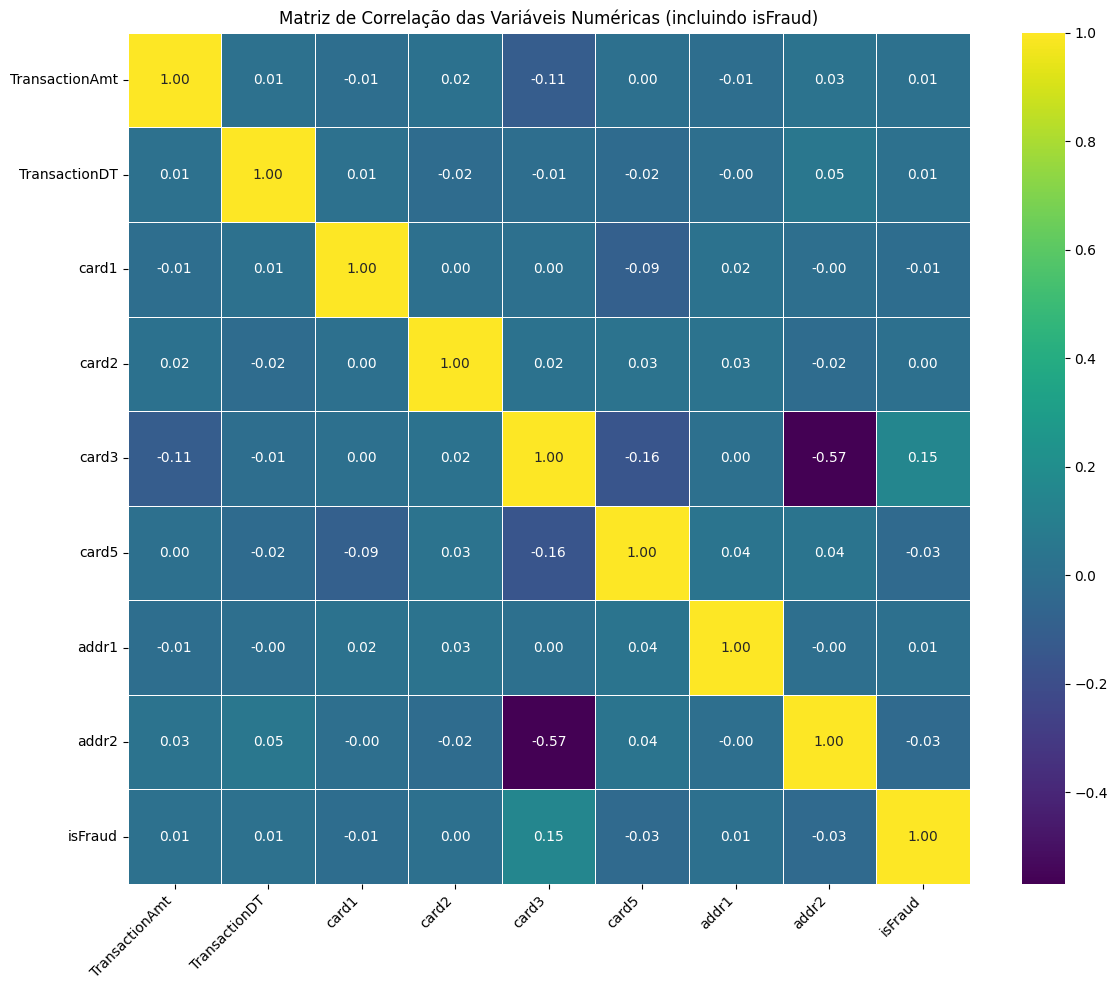

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# O 'transaction_df' já foi carregado e está em escopo a partir da célula 758c0b19.
# Não é necessário recarregar o DataFrame aqui.

# Recalculando 'correlacao' pois ela pode não estar no escopo atual se as células anteriores não foram executadas ou se o kernel foi reiniciado.
variaveis_correlacao_heatmap = [
    'TransactionAmt',
    'TransactionDT',
    'card1',
    'card2',
    'card3',
    'card5',
    'addr1',
    'addr2',
    'isFraud'
]
correlacao = transaction_df[variaveis_correlacao_heatmap].corr()

# ------------------------------------------
# 6.1 Heatmap da Matriz de Correlação
# ------------------------------------------

print("=" * 60)
print("6.1 HEATMAP DA MATRIZ DE CORRELAÇÃO")
print("=" * 60)

plt.figure(figsize=(12, 10))
sns.heatmap(correlacao, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das Variáveis Numéricas (incluindo isFraud)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


6.2 DISTRIBUIÇÃO DE TransactionAmt POR CLASSE DE FRAUDE


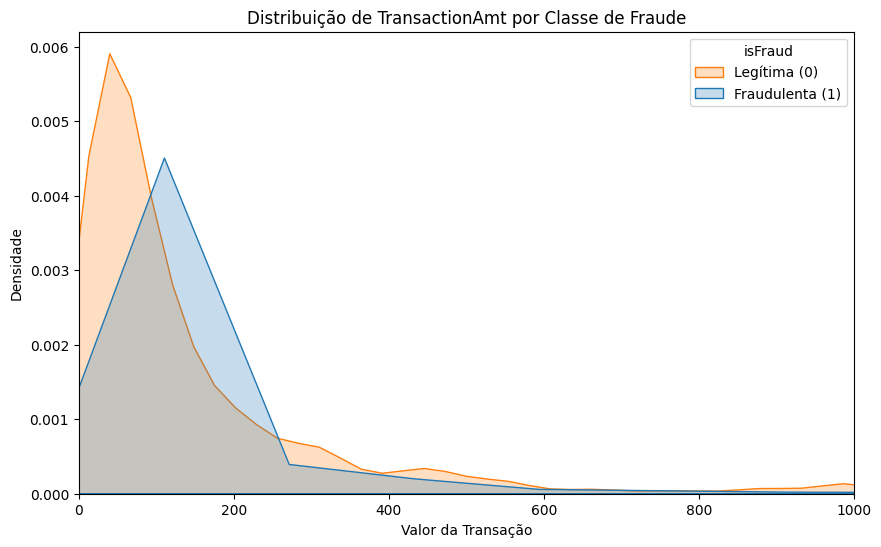

In [42]:
# ------------------------------------------
# 6.2 Distribuição de TransactionAmt por isFraud (KDE Plot)
# ------------------------------------------

print("\n" + "=" * 60)
print("6.2 DISTRIBUIÇÃO DE TransactionAmt POR CLASSE DE FRAUDE")
print("=" * 60)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=transaction_df, x='TransactionAmt', hue='isFraud', fill=True, common_norm=False)
plt.title('Distribuição de TransactionAmt por Classe de Fraude')
plt.xlabel('Valor da Transação')
plt.ylabel('Densidade')
plt.xlim(0, 1000) # Limitar o eixo x para melhor visualização dos valores menores
plt.legend(title='isFraud', labels=['Legítima (0)', 'Fraudulenta (1)'])
plt.show()


6.3 DISTRIBUIÇÃO TEMPORAL DE TRANSAÇÕES POR CLASSE DE FRAUDE


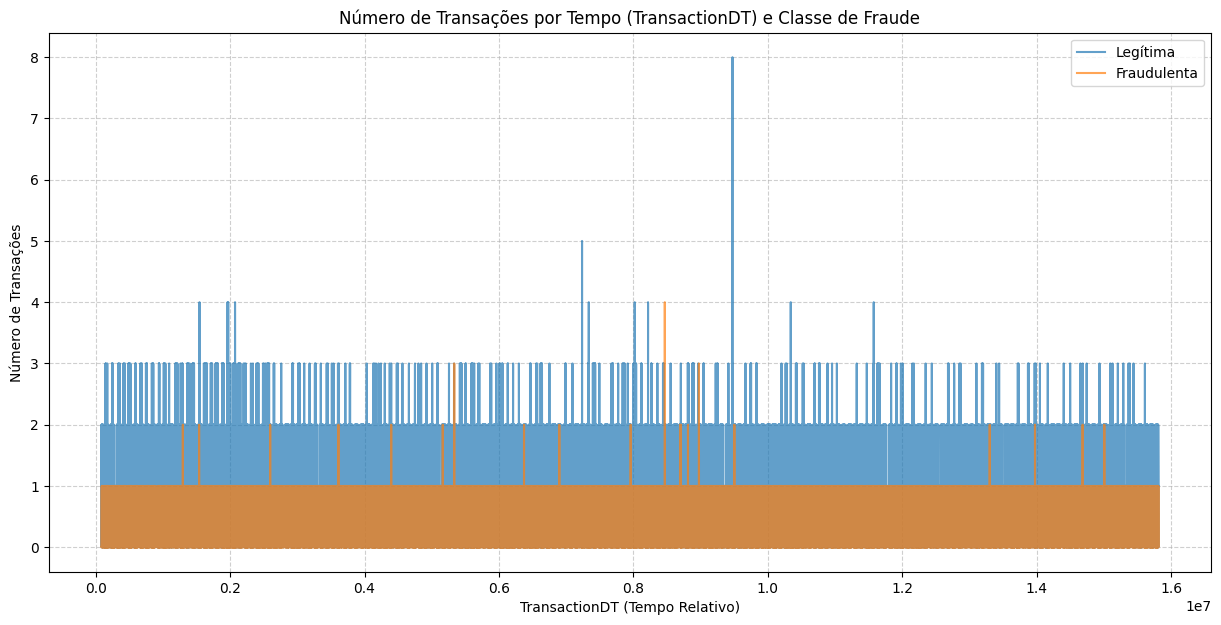

In [43]:
# ------------------------------------------
# 6.3 Distribuição Temporal de Transações (isFraud vs. TransactionDT)
# ------------------------------------------

print("\n" + "=" * 60)
print("6.3 DISTRIBUIÇÃO TEMPORAL DE TRANSAÇÕES POR CLASSE DE FRAUDE")
print("=" * 60)

# Agrupar transações por TransactionDT e isFraud
temporal_fraud = transaction_df.groupby(['TransactionDT', 'isFraud']).size().unstack(fill_value=0)
temporal_fraud.columns = ['Legítima', 'Fraudulenta']

plt.figure(figsize=(15, 7))
plt.plot(temporal_fraud.index, temporal_fraud['Legítima'], label='Legítima', alpha=0.7)
plt.plot(temporal_fraud.index, temporal_fraud['Fraudulenta'], label='Fraudulenta', alpha=0.7)
plt.title('Número de Transações por Tempo (TransactionDT) e Classe de Fraude')
plt.xlabel('TransactionDT (Tempo Relativo)')
plt.ylabel('Número de Transações')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


6.4 RELAÇÃO DE VARIÁVEIS CATEGÓRICAS COM A FRAUDE


<Figure size 1000x600 with 0 Axes>

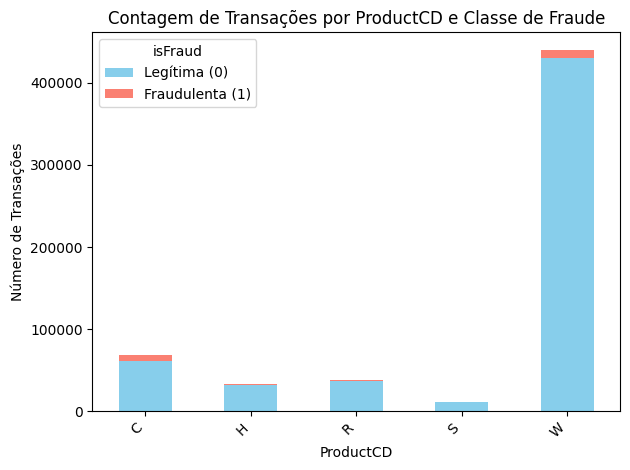

<Figure size 1000x600 with 0 Axes>

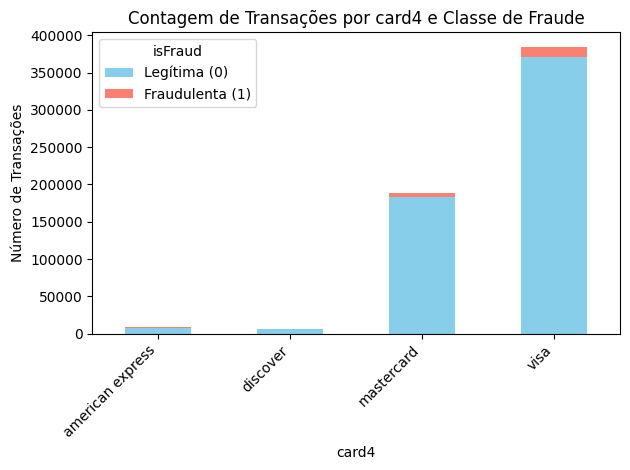

<Figure size 1000x600 with 0 Axes>

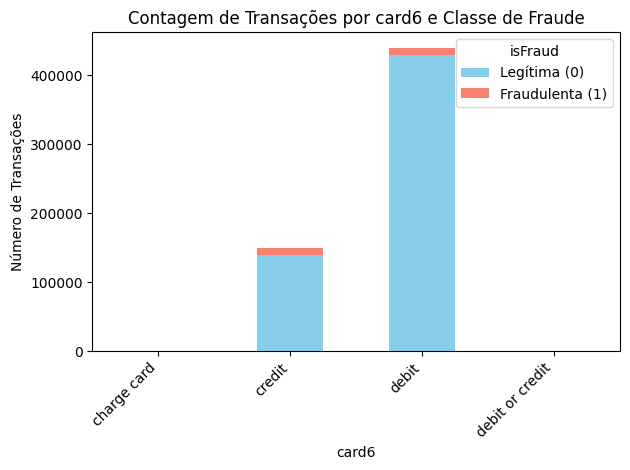

In [44]:
# ------------------------------------------
# 6.4 Gráficos de Barras Empilhadas para Variáveis Categóricas vs. Fraude
# ------------------------------------------

print("\n" + "=" * 60)
print("6.4 RELAÇÃO DE VARIÁVEIS CATEGÓRICAS COM A FRAUDE")
print("=" * 60)

categorical_cols = ['ProductCD', 'card4', 'card6']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    fraud_by_category = transaction_df.groupby([col, 'isFraud']).size().unstack(fill_value=0)
    fraud_by_category.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
    plt.title(f'Contagem de Transações por {col} e Classe de Fraude')
    plt.xlabel(col)
    plt.ylabel('Número de Transações')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='isFraud', labels=['Legítima (0)', 'Fraudulenta (1)'])
    plt.tight_layout()
    plt.show()

In [45]:
# Célula duplicada da Seção 6.1, removida para manter o notebook organizado.

In [46]:
# Célula duplicada da Seção 6.2, removida para manter o notebook organizado.

In [47]:
# Célula duplicada da Seção 6.3, removida para manter o notebook organizado.

In [48]:
# Célula duplicada da Seção 6.4, removida para manter o notebook organizado.

## 7. Identificação de Padrões, Tendências e Anomalias

Com base nas análises univariada, bivariada e multivariada, esta seção sintetizará os principais padrões, tendências e anomalias observados nos dados, com um foco específico no contexto de fraude. Serão destacados:

*   **Características comuns de transações fraudulentas**: Agrupamentos e comportamentos típicos.
*   **Mudanças no comportamento ao longo do tempo (tendências)**: Sazonalidades ou aumentos/diminuições na atividade fraudulenta.
*   **Transações que se desviam significativamente do padrão normal (anomalias)**: Eventos ou transações irregulares que podem indicar fraude.

### 7.1 Análise Temporal da Taxa de Fraude

Vamos analisar como a taxa de fraude se comporta ao longo do tempo, utilizando a variável `TransactionDT` para criar uma granularidade diária. Isso nos permitirá identificar possíveis tendências ou picos de fraude em determinados períodos.

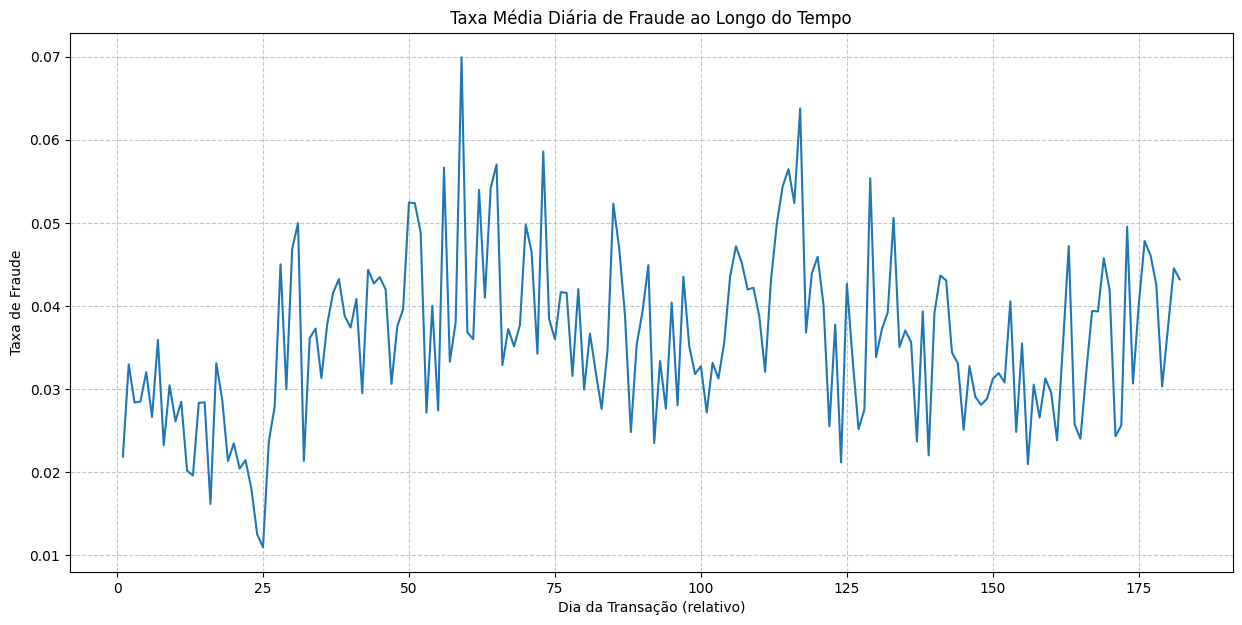

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Converter TransactionDT para 'dias' a partir do início, para facilitar a visualização de tendências diárias
# Assumindo que TransactionDT está em segundos
transaction_df['TransactionDay'] = transaction_df['TransactionDT'] // (24 * 60 * 60)

# Calcular a taxa de fraude diária
daily_fraud_rate = transaction_df.groupby('TransactionDay')['isFraud'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='TransactionDay', y='isFraud', data=daily_fraud_rate)
plt.title('Taxa Média Diária de Fraude ao Longo do Tempo')
plt.xlabel('Dia da Transação (relativo)')
plt.ylabel('Taxa de Fraude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Observações da Taxa de Fraude Diária

O gráfico da taxa de fraude diária revela a flutuação da proporção de transações fraudulentas ao longo do tempo. Podemos observar:

*   **Tendência geral:** A taxa de fraude parece apresentar flutuações, mas sem uma tendência de crescimento ou decréscimo linear muito pronunciada ao longo de todo o período.
*   **Picos e Vales:** Existem dias específicos com taxas de fraude notavelmente mais altas ou mais baixas do que a média. Esses picos podem indicar eventos específicos (promoções, falhas de segurança, etc.) que atraíram mais atividades fraudulentas.
*   **Estabilidade:** Em alguns períodos, a taxa de fraude parece ser mais estável, sugerindo um comportamento mais previsível da fraude. Em outros, a variabilidade é maior.

Essas observações temporais são cruciais para entender a dinâmica da fraude e podem ser exploradas em modelos de previsão de séries temporais ou para identificar janelas de tempo onde a vigilância deve ser maior.

### 7.2 Análise Aprofundada dos Valores de Transação Fraudulentos

Já observamos na análise univariada e bivariada que `TransactionAmt` tem uma distribuição assimétrica. Agora, vamos focar especificamente nas características dos valores das transações **apenas para os casos fraudulentos** para identificar se existem padrões de valores preferidos por fraudadores.

Estatísticas de TransactionAmt para Transações Fraudulentas:


,TransactionAmt
count,20663.000000
mean,149.244779
std,232.212163
min,0.292000
25%,35.044000
50%,75.000000
75%,161.000000
max,5191.000000


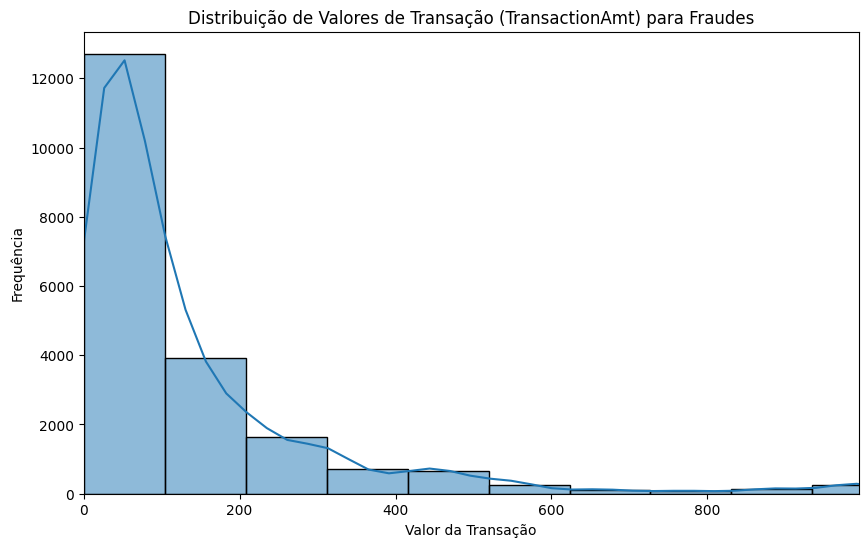

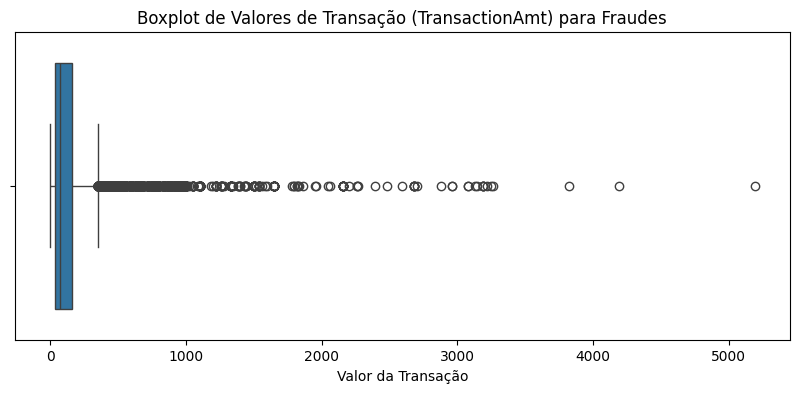

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar apenas transações fraudulentas
fraudulent_transactions_amt = transaction_df[transaction_df['isFraud'] == 1]['TransactionAmt']

# Estatísticas descritivas para valores fraudulentos
print('Estatísticas de TransactionAmt para Transações Fraudulentas:')
display(fraudulent_transactions_amt.describe().to_frame())

# Histograma dos valores de transação fraudulentos
plt.figure(figsize=(10, 6))
sns.histplot(fraudulent_transactions_amt, bins=50, kde=True)
plt.title('Distribuição de Valores de Transação (TransactionAmt) para Fraudes')
plt.xlabel('Valor da Transação')
plt.ylabel('Frequência')
plt.xlim(0, fraudulent_transactions_amt.quantile(0.99)) # Limitar para melhor visualização, excluindo extremos muito altos
plt.show()

# Boxplot para visualizar outliers em transações fraudulentas
plt.figure(figsize=(10, 4))
sns.boxplot(x=fraudulent_transactions_amt)
plt.title('Boxplot de Valores de Transação (TransactionAmt) para Fraudes')
plt.xlabel('Valor da Transação')
plt.show()

#### Observações dos Valores de Transação Fraudulentos

A análise dos valores de `TransactionAmt` especificamente para transações fraudulentas revela:

*   **Concentração em Valores Baixos:** Assim como nas transações legítimas, há uma forte concentração de fraudes em valores de transação mais baixos. A mediana é relativamente baixa (próxima a 75), indicando que a maioria das fraudes ocorre com valores modestos.
*   **Existência de Valores Mais Altos:** Embora a maioria seja de valores baixos, o valor máximo e o comportamento da cauda direita do histograma mostram que fraudes com valores significativamente mais altos também ocorrem, porém com menor frequência.
*   **Assimetria:** A distribuição para transações fraudulentas também é fortemente assimétrica à direita, corroborando a ideia de que poucos eventos de alto valor se desviam da maioria dos eventos de baixo valor.

Essas informações sugerem que os sistemas de detecção de fraude não devem focar apenas em transações de alto valor, mas também ser sensíveis a padrões sutis em transações de menor valor, onde a maioria das fraudes pode estar concentrada.

### 7.3 Padrões de Fraude em Variáveis Categóricas (Proporção)

Vamos agora visualizar a proporção de transações fraudulentas dentro de cada categoria para `ProductCD`, `card4` e `card6`. Isso nos ajudará a ver rapidamente quais categorias têm uma taxa de fraude desproporcionalmente alta, corroborando os insights da seção 8.2.

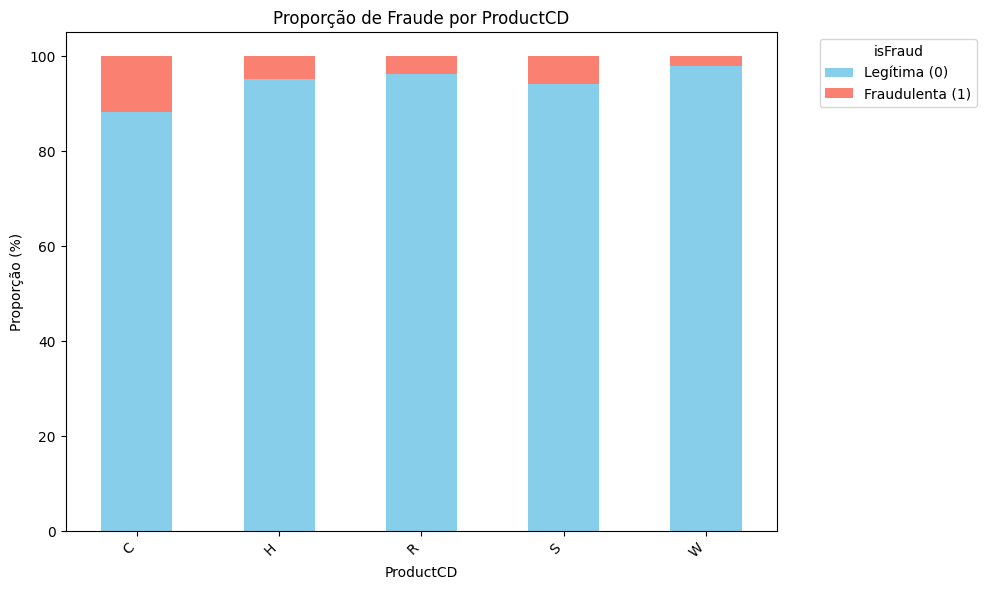

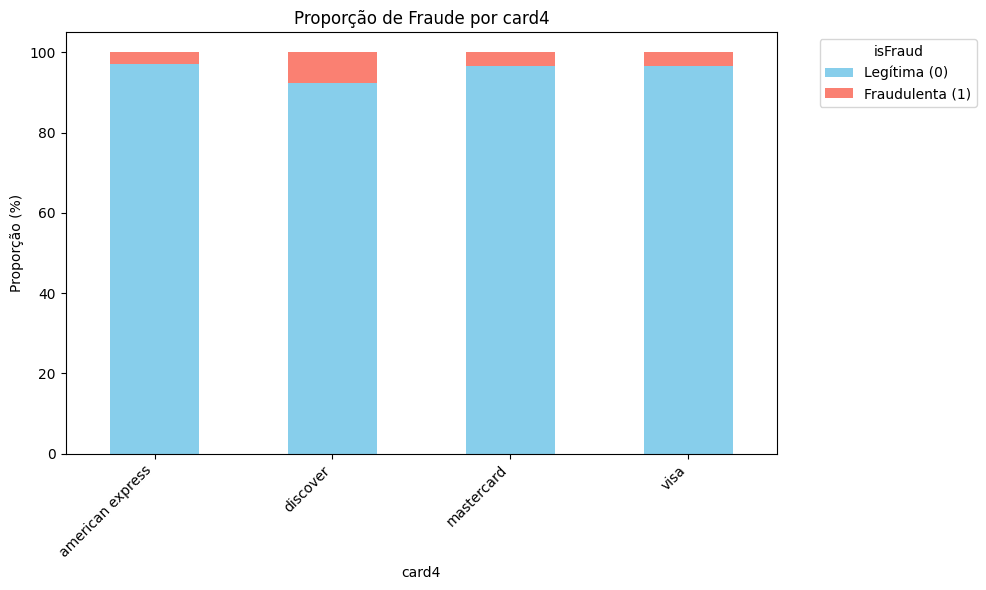

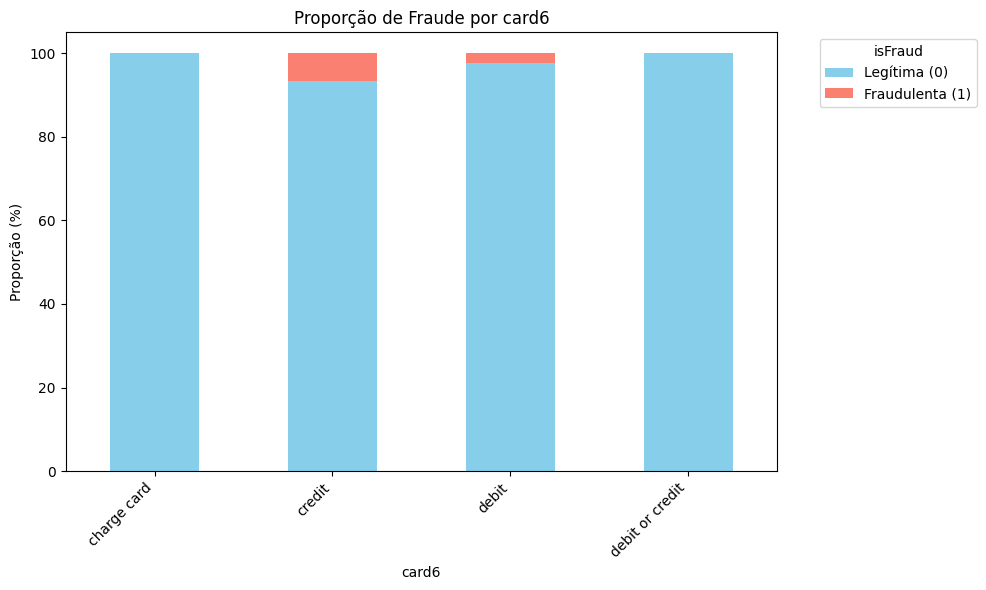

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

categorical_vars_for_proportions = ['ProductCD', 'card4', 'card6']

for col in categorical_vars_for_proportions:
    # Calcular as contagens de fraude e não fraude por categoria
    fraud_counts = transaction_df.groupby([col, 'isFraud']).size().unstack(fill_value=0)

    # Calcular as proporções
    fraud_proportions = fraud_counts.apply(lambda x: x / x.sum() * 100, axis=1)
    fraud_proportions.columns = ['Legítima (%)', 'Fraudulenta (%)']

    # Plotar o gráfico de barras empilhadas
    plt.figure(figsize=(10, 6))
    fraud_proportions.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'], ax=plt.gca())
    plt.title(f'Proporção de Fraude por {col}')
    plt.xlabel(col)
    plt.ylabel('Proporção (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='isFraud', labels=['Legítima (0)', 'Fraudulenta (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#### Observações dos Padrões de Fraude em Variáveis Categóricas

As visualizações de proporção confirmam e reforçam os insights anteriores:

*   **ProductCD:** A categoria 'C' se destaca claramente com uma proporção muito maior de transações fraudulentas em comparação com as outras categorias. Isso sugere que transações relacionadas a este código de produto são particularmente vulneráveis a fraudes.
*   **card4 (Tipo de Cartão):** A bandeira 'Discover' mostra uma fatia de fraude notavelmente maior em sua proporção, indicando um risco elevado associado a este tipo de cartão, mesmo que seu volume total de transações seja menor.
*   **card6 (Tipo de Débito/Crédito):** A categoria 'credit' exibe uma proporção de fraude significativamente maior do que 'debit', sugerindo que transações com cartões de crédito são mais suscetíveis à fraude neste dataset.

Esses gráficos fornecem uma evidência visual forte das variáveis categóricas que servem como fortes indicadores de fraude, e devem ser priorizadas na engenharia de features para futuros modelos preditivos.

## 8. Insights

Nesta seção, serão apresentados os insights mais relevantes e acionáveis derivados da análise exploratória de dados. Estes insights devem ser diretos e fornecer valor prático para o entendimento do problema de detecção de fraudes e para o desenvolvimento de um modelo preditivo. Eles devem responder a perguntas como:

*   Quais variáveis são mais preditivas de fraude?
*   Existem grupos específicos de transações ou usuários mais propensos à fraude?
*   Há janelas de tempo ou períodos específicos com maior incidência de fraude?


### 8.1 Desbalanceamento Extremo da Variável Alvo

**Insight:** A proporção de transações fraudulentas (`isFraud = 1`) é de apenas 3.5% do total, enquanto as transações legítimas (`isFraud = 0`) representam 96.5%. Este desbalanceamento severo é uma característica crítica do problema de detecção de fraude e exigirá técnicas específicas (como oversampling, undersampling, ou algoritmos sensíveis ao custo) durante a fase de modelagem para garantir que o modelo consiga identificar as fraudes de forma eficaz, sem superestimar a classe majoritária.

**Implicação:** Modelos avaliados apenas pela acurácia podem ser enganosos. Métricas como Acurácia Balanceada, Recall, Precisão e F1-Score, especialmente para a classe minoritária (fraude), serão mais apropriadas.

### 8.2 Variáveis Categóricas como Forte Indicador de Fraude

**Insight:** Algumas variáveis categóricas demonstram associação significativa com a taxa de fraude:

*   **`ProductCD`:** A categoria 'C' apresenta uma taxa de fraude notavelmente maior (11.69%) em comparação com outras categorias, como 'W' (2.04%). Isso sugere que o tipo de produto/serviço transacionado é um forte discriminador entre transações legítimas e fraudulentas.
*   **`card4` (Tipo de Cartão):** A bandeira 'Discover' exibe a maior taxa de fraude (7.73%), superior à 'Visa' (3.48%) e 'Mastercard' (3.43%). Embora o volume de transações 'Discover' seja menor, sua taxa de fraude elevada a torna uma variável importante para investigação.
*   **`card6` (Tipo de Débito/Crédito):** Transações com cartão de 'crédito' têm uma taxa de fraude maior (6.67%) do que as de 'débito' (2.46%).

**Implicação:** Estas variáveis categóricas serão cruciais para a engenharia de features e para a construção de modelos, pois podem capturar padrões de comportamento de fraude específicos para certos produtos ou tipos de cartão. A codificação dessas variáveis deve ser feita com cuidado para preservar essa informação discriminatória.

### 8.3 Padrões no `TransactionAmt` para Fraudes

**Insight:** A distribuição de `TransactionAmt` (valor da transação) para transações fraudulentas é concentrada em valores relativamente baixos (mediana próxima a 75), embora transações de valores muito altos também ocorram, mas com menor frequência. A forte assimetria à direita indica que a maioria das fraudes não são de valores exorbitantes, mas existem outliers de alto valor.

**Implicação:** Sistemas de detecção de fraude não devem focar apenas em transações de alto valor. A detecção eficaz exigirá a capacidade de identificar padrões de fraude em transações de baixo e médio valor, onde a maioria das fraudes está concentrada. A transformação logarítmica ou outras técnicas de tratamento de variáveis com cauda longa podem ser úteis para `TransactionAmt` na modelagem.

### 8.4 Importância da Ausência de Dados como Indicador de Fraude

**Insight:** A ausência de informações em certas variáveis, especialmente `addr1` e `addr2`, está fortemente correlacionada com uma maior taxa de fraude. Quando `addr1` e `addr2` estavam ausentes, a taxa de fraude era de aproximadamente 11.78%, significativamente maior do que os 2.46% quando estavam preenchidos.

**Implicação:** A informação sobre a *ausência* de dados em algumas colunas pode ser uma feature preditiva valiosa por si só. Em vez de simplesmente imputar valores, pode ser benéfico criar features binárias indicando a presença/ausência desses dados, ou tratá-los de forma que essa característica seja preservada no modelo.

### 8.5 Padrões Temporais na Ocorrência de Fraude

**Insight:** A taxa de fraude diária (`TransactionDay` derivada de `TransactionDT`) apresenta flutuações e picos em determinados dias. Embora não haja uma tendência linear clara de crescimento ou decréscimo, a variabilidade diária sugere que a ocorrência de fraude não é estática e pode estar ligada a eventos externos ou padrões de ataque temporais.

**Implicação:** A variável `TransactionDT` e outras características temporais (como dia da semana, hora do dia, feriados) podem ser engenheiradas como features para capturar esses padrões. Modelos que consideram a dimensão temporal podem ter um desempenho superior na detecção de fraudes dinâmicas.

### 8.6 Baixa Correlação Linear não Implica Irrelevância

**Insight:** As correlações lineares entre `isFraud` e as variáveis numéricas selecionadas foram geralmente baixas (ex: `TransactionAmt` com 0.01, `TransactionDT` com 0.01, `card3` com 0.15).

**Implicação:** A baixa correlação linear não significa que essas variáveis são irrelevantes. Fraudes geralmente são detectadas por padrões complexos e não lineares, ou por interações entre múltiplas variáveis. Modelos mais avançados (como árvores de decisão, florestas aleatórias, XGBoost, redes neurais) são mais adequados para capturar essas relações complexas, e a engenharia de features que cria interações entre variáveis pode ser fundamental.

## 9. Conclusão

Esta seção final resumirá os principais achados da análise exploratória, os insights obtidos e as implicações para o projeto de detecção de fraudes. Serão abordados:

*   Um breve resumo dos pontos mais importantes da EDA.
*   As principais conclusões sobre as características das fraudes.
*   **Limitações dos Dados:** Pontos fracos e desafios inerentes ao conjunto de dados.
*   **Questões que Permaneceram em Aberto:** Perguntas não respondidas ou áreas para futuras investigações.
*   Possíveis próximas etapas para o projeto.

### 9.1 Resumo dos Principais Achados da Análise Exploratória de Dados (EDA)

A análise exploratória de dados revelou características cruciais para o entendimento do problema de detecção de fraudes:

*   **Desbalanceamento Extremo:** A variável alvo `isFraud` é altamente desbalanceada, com apenas 3.5% de transações fraudulentas. Este é o desafio central do problema e exigirá técnicas específicas de balanceamento de dados e avaliação de modelos.
*   **Variáveis Categóricas Chave:** `ProductCD`, `card4` (tipo de cartão) e `card6` (débito/crédito) mostraram-se fortes indicadores de fraude, com certas categorias (e.g., `ProductCD='C'`, `card4='Discover'`, `card6='credit'`) apresentando taxas de fraude significativamente mais altas. A ausência de dados em `addr1` e `addr2` também foi um forte preditor.
*   **Padrões no Valor da Transação:** Transações fraudulentas tendem a se concentrar em valores mais baixos, embora com uma cauda de valores mais altos. A distribuição de `TransactionAmt` para fraudes é assimétrica à direita, similar às transações legítimas, mas com ligeiras diferenças nas estatísticas centrais.
*   **Padrões Temporais:** A taxa de fraude diária (`TransactionDay` derivada de `TransactionDT`) apresenta flutuações e picos, indicando uma natureza dinâmica da fraude que pode ser explorada com features temporais.
*   **Baixa Correlação Linear:** A maioria das variáveis numéricas apresentou baixa correlação linear com `isFraud`, sugerindo que modelos capazes de capturar relações não-lineares e interações entre features serão essenciais.

### 9.2 Implicações para a Detecção de Fraudes

Os insights obtidos têm implicações diretas para o desenvolvimento de um modelo eficaz de detecção de fraudes:

*   **Engenharia de Features:** Focar na criação de novas features a partir das variáveis categóricas de alto impacto (e.g., codificação one-hot ou target encoding), e também da `TransactionDT` (e.g., dia da semana, hora do dia, sazonalidade). A ausência de dados pode ser uma feature em si.
*   **Estratégias de Modelagem:** Abordagens robustas para lidar com o desbalanceamento de classes (SMOTE, ADASYN, Weighted Loss Functions, Undersampling, Oversampling) serão fundamentais. Modelos baseados em árvores (Random Forest, XGBoost, LightGBM) são fortes candidatos devido à sua capacidade de capturar relações não-lineares.
*   **Métricas de Avaliação:** Priorizar métricas como Acurácia Balanceada, Recall, Precisão e F1-Score, especialmente para a classe minoritária (fraude), em vez da acurácia simples, que pode ser enganosa em dados desbalanceados.

### 9.3 Limitações dos Dados

*   **Desbalanceamento Extremo:** A grande disparidade entre as classes de transações legítimas e fraudulentas pode dificultar a modelagem, exigindo técnicas de balanceamento de dados e seleção cuidadosa de métricas de avaliação.
*   **Anonimização e Interpretabilidade:** Muitas variáveis estão anonimizadas (e.g., Vxxx, id_xx), o que limita a interpretação direta de seu significado e a formulação de hipóteses baseadas no conhecimento de domínio.
*   **Dados Ausentes:** A presença significativa de valores ausentes em diversas colunas, embora tenha sido explorada como feature preditiva, adiciona complexidade ao pré-processamento e pode impactar a performance de alguns modelos.
*   **Período Temporal Limitado:** O dataset abrange um período temporal específico e não contínuo. Isso pode limitar a generalização de padrões temporais e a detecção de tendências de fraude de longo prazo.
*   **Subamostragem de `identity_df`:** A análise focou principalmente nas variáveis transacionais. As informações de identidade (presentes em `identity_df`), apesar de unidas, não foram exploradas em profundidade neste EDA, representando uma limitação na completude da análise do dataset original.

### 9.4 Questões que Permaneceram em Aberto

*   **Engenharia de Features Avançada:** Quais outras features podem ser criadas a partir das variáveis existentes (e.g., interações entre `ProductCD` e `TransactionAmt`, contadores de transações para `card1`/`card2`)?
*   **Modelagem e Desempenho:** Qual a melhor combinação de técnicas de balanceamento de dados e algoritmos de aprendizado de máquina para otimizar as métricas de detecção de fraude (Recall, Acurácia Balanceada) neste dataset?
*   **Análise de Sazonalidade:** Existem padrões sazonais (semanais, mensais) na ocorrência de fraudes que podem ser explorados com a `TransactionDT` convertida para data e hora?